In [218]:
from pathlib import Path

import pandas as pd
from acteval.describe.frequency import frequency_plots, plot_agg_acts
from acteval.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from acteval.describe.transitions import _probs_plot, sequence_prob_plot
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

In [219]:
cmaps = {
    "home": (0.55, 0.71, 0.82),  # #8CB6D1 steel blue
    "work": (0.88, 0.36, 0.32),  # #E15C52 red
    "education": (0.96, 0.78, 0.26),  # #F5C742 golden yellow
    "shop": (0.61, 0.49, 0.78),  # #9C7DC7 purple
    "visit": (0.94, 0.53, 0.23),  # #F0873B amber
    "escort": (0.29, 0.75, 0.73),  # #4ABFBA teal
    "medical": (0.94, 0.53, 0.60),  # #F0879A rose
    "travel": (0.62, 0.62, 0.62),  # #9E9E9E mid grey
    "other": (0.71, 0.80, 0.48),  # #B5CC7A sage green
}

batch_paths = {
    "Compositional": Path("../logs/actvae/compositional"),
    # "MDCEV": Path("../logs/actvae/mdcev"),
    # "ActVAE": Path("../logs/actvae/cpvae"),
    # "Disc RNN": Path("../logs/TRB/discrim"),
    "ActVAE-Cond": Path("../logs/actvae/conditional"),
    "ActVAE-Gen": Path("../logs/actvae/vae"),
    "ActVAE": Path("../logs/actvae/cpvae"),
    # "LLM": Path("../logs/actvae/llm"),
    # "LLM-ft": Path("../logs/actvae/llm_ft"),
}

# find data
target_schedules = pd.read_csv("~/Data/foundata/out/nts/2023/activities.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv(
    "~/Data/foundata/out/nts/2023/attributes_binned.csv"
)


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    if not versions:
        return path.name, path
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "eval" / "domains" / "distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "eval" / "domains" / "distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))] for k, v in splits
    }

/tmp/ipykernel_41034/279630222.py:30: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  target_attributes = pd.read_csv(


In [220]:
schedules = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(next(best_quality(p, 0))[1], default=target_attributes)
    for n, p in batch_paths.items()
}

Loading synthetic attributes from ../logs/actvae/compositional/seed_11111
Loading synthetic attributes from ../logs/actvae/conditional/conditional_nrun0/version_0
Loading synthetic attributes from ../logs/actvae/vae/vae_nrun0/version_0
Loading synthetic attributes from ../logs/actvae/cpvae/cpvae-add_nrun0/version_0


In [221]:
def build_distance_tables(batch_paths):
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / "eval" / "domains" / "distances.csv"
        ).set_index("domain")

        columns = list(
            set(distances.columns) - set(["domain", "observed", "mean", "std"])
        )
        distances_combined[(name, "EMD")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    # distances_combined = distances_combined.set_index(
    #     pd.MultiIndex.from_tuples(distances_combined.index)
    # )

    return distances_combined


order = ["participations", "transitions", "timing", "feasibility", "creativity"]
df = build_distance_tables(batch_paths)
print(df.loc[order].to_latex(float_format="{:.3f}".format))
df

\begin{tabular}{lrrrrrrrr}
\toprule
 & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{ActVAE} \\
 & EMD & var & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  &  &  \\
\midrule
participations & 0.084 & 0.000 & 0.402 & 0.000 & 0.117 & 0.000 & 0.083 & 0.000 \\
transitions & 0.004 & 0.000 & 0.020 & 0.000 & 0.007 & 0.000 & 0.004 & 0.000 \\
timing & 0.080 & 0.000 & 0.200 & 0.000 & 0.057 & 0.000 & 0.047 & 0.000 \\
feasibility & 0.000 & 0.000 & 0.000 & 0.000 & 0.015 & 0.000 & 0.015 & 0.000 \\
creativity & 0.060 & 0.000 & 0.264 & 0.000 & 0.030 & 0.000 & 0.032 & 0.000 \\
\bottomrule
\end{tabular}



Compositional               ActVAE-Cond                \
                         EMD           var         EMD           var   
domain                                                                 
creativity          0.059834  5.026846e-08    0.263887  2.661078e-05   
feasibility         0.000000  0.000000e+00    0.000113  6.437238e-08   
participations      0.083565  3.998159e-06    0.402156  9.148612e-06   
timing              0.079822  1.260796e-08    0.199801  1.141230e-04   
transitions         0.003753  3.281219e-09    0.020392  3.442013e-07   

               ActVAE-Gen                  ActVAE                
                      EMD           var       EMD           var  
domain                                                           
creativity       0.030135  5.550655e-07  0.031776  1.936154e-07  
feasibility      0.015047  7.636629e-05  0.014670  2.520793e-06  
participations   0.117443  6.505279e-06  0.083007  1.567493e-05  
timing           0.056512  3.933448e-06  0.046785  2.177686e-06  
transitions      0.006664  1.228678e-07  0.003833  4.485888e-07

In [6]:
def group_tables(batch_paths):
    distances_combined = pd.DataFrame()
    descriptions_combined = pd.DataFrame()
    variances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / "eval" / "groups" / "distances.csv"
        ).set_index(["domain", "feature"])
        descriptions = pd.read_csv(
            path / "eval" / "groups" / "descriptions.csv"
        ).set_index(["domain", "feature"])

        columns = set(distances.columns)
        columns = list(
            columns - set(["observed", "unit", "mean", "std", "sub_pop"])
        )

        print(name, columns)

        distances_combined[(name, "mean")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)
        variances_combined[(name, "std")] = distances[columns].std(axis=1)
        descriptions_combined[(name, "mean")] = descriptions[columns].mean(
            axis=1
        )

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )
    variances_combined.columns = pd.MultiIndex.from_tuples(
        variances_combined.columns
    )
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return (
        distances_combined.loc[index],
        variances_combined,
        descriptions_combined.loc[index],
    )


dist_dist, dist_std, dist_desc = group_tables(batch_paths)
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))

Compositional ['seed_44444', 'seed_11111', 'seed_22222', 'seed_33333', 'seed_55555']
ActVAE-Cond ['conditional_nrun1', 'conditional_nrun3', 'conditional_nrun2', 'conditional_nrun0', 'conditional_nrun4']
ActVAE-Gen ['vae_nrun3', 'vae_nrun2', 'vae_nrun4', 'vae_nrun1', 'vae_nrun0']
ActVAE ['cpvae-add_nrun0', 'cpvae-add_nrun2', 'cpvae-add_nrun3', 'cpvae-add_nrun4', 'cpvae-add_nrun1']
\begin{tabular}{lrrrrrrrr}
\toprule
 & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{ActVAE} \\
 & mean & var & mean & var & mean & var & mean & var \\
feature &  &  &  &  &  &  &  &  \\
\midrule
lengths & 0.199 & 0.000 & 0.997 & 0.000 & 0.274 & 0.000 & 0.206 & 0.000 \\
pair participation rate & 0.008 & 0.000 & 0.018 & 0.000 & 0.006 & 0.000 & 0.004 & 0.000 \\
participation rate & 0.044 & 0.000 & 0.191 & 0.000 & 0.073 & 0.000 & 0.039 & 0.000 \\
2-gram & 0.007 & 0.000 & 0.049 & 0.000 & 0.015 & 0.000 & 0.008 & 0.000 \\
3-gram & 0.002 & 0.

In [236]:
def build_all_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(
            path / "eval" / "features" / "descriptions.csv"
        ).set_index(["domain", "feature", "segment"])
        distances = pd.read_csv(
            path / "eval" / "features" / "distances.csv"
        ).set_index(["domain", "feature", "segment"])
        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(
                [
                    "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
            - weights
        )
        descriptions_combined[name, "mean"] = descriptions[columns].mean(axis=1)
        # descriptions_combined[name, "var"] = descriptions[columns].var(axis=1)
        descriptions_combined[name, "EMD"] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["unit"]
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )
    descriptions_combined = descriptions_combined.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(
        lambda x: x.sort_values([("Observed", "")], ascending=False).head(20)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return descriptions_combined.loc[index, order]


table = build_all_description_tables(batch_paths)

p = table.loc["participations"]
for name in ["lengths", "participation rate", "pair participation rate"]:
    print(name)
    print(p.loc[name].to_latex(float_format="{:.3f}".format))
    print()

table.loc["participations"]

lengths
\begin{tabular}{lrrrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  &  &  \\
\midrule
sequence lengths & 3.931 & 3.834 & 0.199 & 3.012 & 0.997 & 3.863 & 0.274 & 3.887 & 0.206 & length. \\
\bottomrule
\end{tabular}


participation rate
\begin{tabular}{lrrrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  &  &  \\
\midrule
home & 2.326 & 2.324 & 0.075 & 2.006 & 0.372 & 2.273 & 0.128 & 2.291 & 0.105 & av. rate \\
other & 0.531 & 0.498 & 0.065 & 0.498 & 0.216 & 0.463 & 0.100 & 0.535 & 0.050 & av. rate \\
shop & 0.298 & 0.278 & 0.030 & 0.027 &

Observed Compositional            \
                                                               mean       EMD   
feature                 segment                                                 
lengths                 sequence lengths     3.930729      3.833958  0.199158   
pair participation rate home+home            1.055170      1.052037  0.033885   
                        other+other          0.086897      0.058112  0.030486   
                        home+other           0.084394      0.058112  0.027970   
                        escort+escort        0.076145      0.029193  0.047569   
                        escort+home          0.073060      0.029193  0.044485   
                        shop+shop            0.034124      0.020718  0.013986   
                        home+shop            0.033472      0.020718  0.013341   
                        visit+visit          0.013572      0.002704  0.010955   
                        home+visit           0.013343      0.002704  0.010723   
                        home+work            0.010311      0.000000  0.010306   
                        work+work            0.010311      0.000000  0.010306   
                        escort+other         0.004759      0.002069  0.002770   
                        other+shop           0.002820      0.001121  0.001748   
                        escort+shop          0.002203      0.000575  0.001637   
                        other+visit          0.001833      0.000095  0.001765   
                        home+medical         0.001622      0.000469  0.001167   
                        medical+medical      0.001622      0.000469  0.001167   
                        education+education  0.001128      0.000000  0.001116   
                        education+home       0.001128      0.000000  0.001116   
                        shop+visit           0.000969      0.000063  0.000910   
participation rate      home                 2.325642      2.323886  0.075078   
                        other                0.530617      0.497517  0.065318   
                        shop                 0.297864      0.278028  0.029947   
                        escort               0.257676      0.254113  0.124533   
                        work                 0.254644      0.246176  0.019829   
                        visit                0.129799      0.106757  0.026193   
                        education            0.091162      0.090120  0.006730   
                        medical              0.043325      0.041610  0.004012   

                                            ActVAE-Cond           ActVAE-Gen  \
                                                   mean       EMD       mean   
feature                 segment                                                
lengths                 sequence lengths       3.012324  0.997125   3.862901   
pair participation rate home+home              1.000208  0.081328   1.046287   
                        other+other            0.000427  0.086647   0.068453   
                        home+other             0.000427  0.084127   0.066634   
                        escort+escort          0.005595  0.071690   0.049657   
                        escort+home            0.005595  0.068569   0.048324   
                        shop+shop              0.000000  0.034873   0.034774   
                        home+shop              0.000000  0.034211   0.033667   
                        visit+visit            0.000000  0.013572   0.010259   
                        home+visit             0.000000  0.013343   0.010001   
                        home+work              0.000000  0.010400   0.010509   
                        work+work              0.000000  0.010400   0.010509   
                        escort+other           0.000000  0.004797   0.002588   
                        other+shop             0.000000  0.002882   0.001826   
                        escort+shop            0.000000  0.002247   0.001361   
            

In [240]:
table.loc[("transitions", "3-gram")]

/tmp/ipykernel_41034/707558163.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  table.loc[("transitions", "3-gram")]


Observed Compositional           ActVAE-Cond            \
                                       mean       EMD        mean       EMD   
segment                                                                       
home>other>home      0.396094      0.405057  0.031132    0.498167  0.215375   
home>work>home       0.210509      0.203933  0.014945    0.349200  0.144978   
home>shop>home       0.193323      0.202368  0.014970    0.026808  0.172544   
home>escort>home     0.143723      0.174109  0.069530    0.028067  0.118594   
home>education>home  0.079899      0.078289  0.006320    0.126349  0.043567   
home>visit>home      0.076726      0.068774  0.010168    0.000000  0.076726   
other>home>other     0.051116      0.046517  0.006538    0.000427  0.050801   
escort>home>escort   0.038954      0.020137  0.019406    0.005645  0.034214   
home>medical>home    0.030775      0.030914  0.002835    0.000000  0.030775   
shop>home>other      0.030264      0.027939  0.003664    0.000000  0.030264   
home>other>other     0.022385      0.000000  0.022385    0.000000  0.022385   
other>other>home     0.021504      0.000000  0.021504    0.000000  0.021504   
other>home>shop      0.021469      0.023017  0.002684    0.000000  0.021469   
escort>home>other    0.019353      0.021075  0.003291    0.000043  0.019324   
work>home>other      0.018278      0.017004  0.002424    0.000022  0.018344   
home>escort>escort   0.017168      0.000000  0.017168    0.000000  0.017168   
other>shop>home      0.016639      0.023151  0.006839    0.000000  0.016639   
shop>shop>home       0.016516      0.000000  0.016516    0.000000  0.016516   
escort>escort>home   0.016498      0.000000  0.016498    0.000000  0.016498   
home>other>shop      0.016498      0.024258  0.007939    0.000000  0.016498   

                    ActVAE-Gen              ActVAE           Description  
                          mean       EMD      mean       EMD              
segment                                                                   
home>other>home       0.293110  0.112968  0.360656  0.054614    av. rate  
home>work>home        0.190473  0.075299  0.204088  0.025072    av. rate  
home>shop>home        0.167880  0.051130  0.157387  0.042078    av. rate  
home>escort>home      0.132141  0.042666  0.121701  0.033848    av. rate  
home>education>home   0.083589  0.047539  0.072288  0.012088    av. rate  
home>visit>home       0.083845  0.015267  0.083278  0.019637    av. rate  
other>home>other      0.034365  0.019529  0.041389  0.011528    av. rate  
escort>home>escort    0.022319  0.018815  0.029855  0.011782    av. rate  
home>medical>home     0.050482  0.022928  0.042103  0.013227    av. rate  
shop>home>other       0.019407  0.013032  0.021416  0.009754    av. rate  
home>other>other      0.024045  0.007596  0.032799  0.011553    av. rate  
other>other>home      0.022364  0.006724  0.031998  0.011881    av. rate  
other>home>shop       0.017028  0.007745  0.018716  0.004284    av. rate  
escort>home>other     0.015709  0.006042  0.021398  0.004786    av. rate  
work>home>other       0.010879  0.010029  0.015762  0.005449    av. rate  
home>escort>escort    0.015853  0.005035  0.018298  0.004281    av. rate  
other>shop>home       0.015542  0.004069  0.022435  0.006338    av. rate  
shop>shop>home        0.017880  0.005757  0.017887  0.003365    av. rate  
escort>escort>home    0.014288  0.004965  0.018643  0.004751    av. rate  
home>other>shop       0.016451  0.004210  0.022128  0.006004    av. rate

In [319]:
def build_cats_table(batch_paths):
    combined = pd.DataFrame()

    for name, path in batch_paths.items():
        label_distances = pd.read_csv(
            path / "eval" / "domains_by_category" / "distances.csv"
        ).set_index(["domain", "label", "cat"])

        columns = set(label_distances.columns)
        # unit = label_distances["unit"].groupby(["domain", "label"]).first()

        columns = list(
            columns
            - set(
                [
                    # "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                    "label",
                    "domain",
                    "feature",
                    "segment",
                ]
            )
        )
        label_distances = (
            label_distances[columns].groupby(["domain", "label", "cat"]).mean()
        )

        combined[name, "EMD"] = label_distances.mean(axis=1)
        # descriptions_combined[name, "var"] = label_distances.var(axis=1)

    # descriptions_combined["Description", ""] = unit
    combined.columns = pd.MultiIndex.from_tuples(combined.columns)

    combined = combined.drop(
        combined.index[combined.index.get_level_values("cat") == "unknown"]
    )

    order = list(combined.columns)

    index = ["participations", "transitions", "timing"]

    return combined.loc[index, order]


table = build_cats_table(batch_paths)

for domain in ["participations", "transitions", "timing"]:
    print(f"Domain: {domain}")
    domain_df = table.loc[domain]
    for label in set(domain_df.index.get_level_values("label")):
        print(f"Label: {label}")
        print(
            domain_df.loc[label]
            .style.highlight_min(axis=1, props="textbf:--rwrap;")
            .format(precision=3)
            .to_latex()
        )

table

Domain: participations
Label: access_egress_distance
\begin{tabular}{lrrrr}
 & Compositional & ActVAE-Cond & ActVAE-Gen & ActVAE \\
 & EMD & EMD & EMD & EMD \\
cat &  &  &  &  \\
3.376-5.8 & 0.057 & 0.433 & 0.100 & \textbf{0.053} \\
5.8-9.15862 & 0.054 & 0.430 & 0.099 & \textbf{0.050} \\
9.15862-15.8 & 0.055 & 0.416 & 0.082 & \textbf{0.048} \\
>15.8 & 0.040 & 0.329 & 0.048 & \textbf{0.036} \\
≤3.376 & \textbf{0.025} & 0.267 & 0.090 & 0.036 \\
\end{tabular}

Label: age
\begin{tabular}{lrrrr}
 & Compositional & ActVAE-Cond & ActVAE-Gen & ActVAE \\
 & EMD & EMD & EMD & EMD \\
cat &  &  &  &  \\
10-21 & \textbf{0.021} & 0.221 & 0.159 & 0.055 \\
21-32 & \textbf{0.034} & 0.310 & 0.065 & 0.050 \\
32-40 & 0.054 & 0.425 & 0.101 & \textbf{0.049} \\
40-48 & 0.074 & 0.479 & 0.170 & \textbf{0.063} \\
48-54 & 0.069 & 0.439 & 0.109 & \textbf{0.052} \\
54-61 & 0.060 & 0.438 & 0.097 & \textbf{0.050} \\
61-68 & 0.059 & 0.430 & 0.101 & \textbf{0.049} \\
68-75 & \textbf{0.043} & 0.421 & 0.094 & 0.059 \\
>

Compositional ActVAE-Cond  \
                                                             EMD         EMD   
domain         label                  cat                                      
participations access_egress_distance 3.376-5.8         0.057305    0.433236   
                                      5.8-9.15862       0.054057    0.429733   
                                      9.15862-15.8      0.055212    0.415884   
                                      >15.8             0.040192    0.329226   
                                      ≤3.376            0.024924    0.267077   
...                                                          ...         ...   
timing         vehicles               3                 0.530829    0.594976   
                                      4                 0.530671    0.584774   
                                      5                 0.549630    0.617368   
                                      6                 0.130103    0.368765   
                                      9                 1.000000    1.000000   

                                                   ActVAE-Gen    ActVAE  
                                                          EMD       EMD  
domain         label                  cat                                
participations access_egress_distance 3.376-5.8      0.100178  0.052850  
                                      5.8-9.15862    0.099354  0.050226  
                                      9.15862-15.8   0.081736  0.047994  
                                      >15.8          0.048167  0.036238  
                                      ≤3.376         0.090163  0.036471  
...                                                       ...       ...  
timing         vehicles               3              0.517678  0.512214  
                                      4              0.525443  0.522127  
                                      5              0.552807  0.542499  
                                      6              0.280010  0.248590  
                                      9              1.000000  1.000000  

[138 rows x 4 columns]

In [ ]:
def build_labels_table(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        label_distances = pd.read_csv(
            path / "eval" / "domains_by_attribute" / "distances.csv"
        ).set_index(["domain", "label"])

        columns = set(label_distances.columns)
        # unit = label_distances["unit"].groupby(["domain", "label"]).first()

        columns = list(
            columns
            - set(
                [
                    # "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                    "cat",
                    "label",
                    "domain",
                    "feature",
                    "segment",
                ]
            )
        )
        label_distances = (
            label_distances[columns].groupby(["domain", "label"]).mean()
        )

        descriptions_combined[name, "EMD"] = label_distances.mean(axis=1)
        # descriptions_combined[name, "var"] = label_distances.var(axis=1)

    # descriptions_combined["Description", ""] = unit
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    order = list(descriptions_combined.columns)

    index = ["participations", "transitions", "timing"]

    return descriptions_combined.loc[index, order]


table = build_labels_table(batch_paths)
for domain in ["participations", "transitions", "timing"]:
    print(f"Domain: {domain}")
    print(
        table.loc[domain]
        .style.highlight_min(axis=1, props="textbf:--rwrap;")
        .format(precision=3)
        .to_latex()
    )
table

Domain: participations
\begin{tabular}{lrrrr}
 & Compositional & ActVAE-Cond & ActVAE-Gen & ActVAE \\
 & EMD & EMD & EMD & EMD \\
label &  &  &  &  \\
access_egress_distance & 0.046 & 0.370 & 0.088 & \textbf{0.045} \\
age & \textbf{0.047} & 0.377 & 0.109 & 0.052 \\
day & 0.045 & 0.372 & 0.066 & \textbf{0.043} \\
employment & \textbf{0.047} & 0.379 & 0.103 & 0.053 \\
hh_income & 0.045 & 0.371 & 0.064 & \textbf{0.040} \\
hh_zone & 0.045 & 0.370 & 0.068 & \textbf{0.040} \\
sex & 0.045 & 0.370 & 0.060 & \textbf{0.040} \\
vehicles & 0.349 & 0.609 & 0.382 & \textbf{0.349} \\
\end{tabular}

Domain: transitions
\begin{tabular}{lrrrr}
 & Compositional & ActVAE-Cond & ActVAE-Gen & ActVAE \\
 & EMD & EMD & EMD & EMD \\
label &  &  &  &  \\
access_egress_distance & 0.003 & 0.020 & 0.005 & \textbf{0.003} \\
age & \textbf{0.003} & 0.021 & 0.010 & 0.004 \\
day & \textbf{0.003} & 0.020 & 0.005 & 0.004 \\
employment & \textbf{0.003} & 0.021 & 0.010 & 0.004 \\
hh_income & 0.003 & 0.020 & 0.005 & \textbf

Compositional ActVAE-Cond ActVAE-Gen  \
                                                EMD         EMD        EMD   
domain         label                                                         
participations access_egress_distance      0.045854    0.370055   0.087551   
               age                         0.047406    0.376730   0.109198   
               day                         0.045260    0.372402   0.066029   
               employment                  0.046661    0.378981   0.103012   
               hh_income                   0.044817    0.370581   0.064103   
               hh_zone                     0.044596    0.369870   0.067974   
               sex                         0.044501    0.369956   0.060013   
               vehicles                    0.349396    0.609031   0.381686   
transitions    access_egress_distance      0.003366    0.019775   0.005451   
               age                         0.003464    0.020712   0.010119   
               day                         0.003310    0.020202   0.005442   
               employment                  0.003315    0.021347   0.010445   
               hh_income                   0.003250    0.019931   0.004872   
               hh_zone                     0.003157    0.019801   0.004452   
               sex                         0.003130    0.019833   0.004363   
               vehicles                    0.007027    0.021563   0.008170   
timing         access_egress_distance      0.054299    0.173686   0.027464   
               age                         0.056071    0.191603   0.047280   
               day                         0.054612    0.172217   0.027404   
               employment                  0.054917    0.188280   0.044128   
               hh_income                   0.053864    0.167857   0.025215   
               hh_zone                     0.053480    0.170133   0.023346   
               sex                         0.053364    0.168617   0.022293   
               vehicles                    0.257986    0.366031   0.234984   

                                         ActVAE  
                                            EMD  
domain         label                             
participations access_egress_distance  0.045196  
               age                     0.052257  
               day                     0.043437  
               employment              0.053041  
               hh_income               0.040356  
               hh_zone                 0.040456  
               sex                     0.039993  
               vehicles                0.349352  
transitions    access_egress_distance  0.003289  
               age                     0.004139  
               day                     0.003506  
               employment              0.004025  
               hh_income               0.003073  
               hh_zone                 0.002986  
               sex                     0.002859  
               vehicles                0.006785  
timing         access_egress_distance  0.019935  
               age                     0.024516  
               day                     0.020929  
               employment              0.024090  
               hh_income               0.019231  
               hh_zone                 0.018603  
               sex                     0.018182  
               vehicles                0.228815

In [341]:
target_attributes.head()

,hid,pid,age,hh_size,hh_income,sex,dwelling,ownership,vehicles,disability,...,source,year,month,day,hh_zone,weight,access_egress_distance,max_temp_c,rain,avg_speed
0,nts2023000001,nts202300000101,>75,2,≤22316,male,unknown,owned,2,no,...,nts,2023,2,monday,suburban,0.624444,5.8-9.15862,unknown,unknown,≤14.8663
1,nts2023000001,nts202300000102,>75,2,≤22316,male,unknown,owned,2,no,...,nts,2023,2,tuesday,suburban,0.624444,5.8-9.15862,unknown,unknown,≤14.8663
2,nts2023000001,nts202300000103,>75,2,≤22316,male,unknown,owned,2,no,...,nts,2023,2,wednesday,suburban,0.624444,5.8-9.15862,unknown,unknown,≤14.8663
3,nts2023000001,nts202300000104,>75,2,≤22316,male,unknown,owned,2,no,...,nts,2023,2,thursday,suburban,0.624444,5.8-9.15862,unknown,unknown,≤14.8663
4,nts2023000001,nts202300000105,>75,2,≤22316,male,unknown,owned,2,no,...,nts,2023,2,friday,suburban,0.624444,5.8-9.15862,unknown,unknown,≤14.8663


In [345]:
# ! pip install statsmodels
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols


def trips_table(schedules, attributes):
    trips = attributes.copy()
    counts = schedules.groupby("pid").size() - 1
    trips = pd.merge(trips, counts.rename("trips"), on="pid")
    trips["vehicles"] = trips["vehicles"].astype("str")
    return trips


def anova_1way(schedules, attributes):
    # 1. PREPARE DATAFRAME
    df = trips_table(schedules, attributes)

    # 2. DEFINE YOUR CATEGORICAL COLUMNS TO TEST
    categorical_cols = [
        "age",
        "day",
        "employment",
        "hh_income",
        "hh_zone",
        "vehicles",
        "access_egress_distance",
        "sex",
    ]

    # 3. LOOP AND RUN THE 1-WAY ANOVA
    for cat in categorical_cols:
        print("\n=========================================")
        print(f"1-Way ANOVA for Categorical Input: {cat}")
        print("=========================================")

        # Formula: trips ~ C(cat) — single factor, no source or interaction
        formula = f"trips ~ C({cat})"

        # Fit the OLS model
        model = ols(formula, data=df).fit()

        # Generate Type II ANOVA table
        anova_table = sm.stats.anova_lm(model, typ=2)

        # Calculate Eta-Squared (effect size)
        anova_table["eta_sq"] = (
            anova_table["sum_sq"] / anova_table["sum_sq"].sum()
        )

        print(anova_table[["df", "F", "PR(>F)", "eta_sq"]])


# Run on observed or generated independently
anova_1way(target_schedules, target_attributes)
# anova_1way(schedules["ActVAE"], attributes["ActVAE"])


1-Way ANOVA for Categorical Input: age
               df           F         PR(>F)    eta_sq
C(age)        9.0  144.338419  6.979466e-271  0.022388
Residual  56724.0         NaN            NaN  0.977612

1-Way ANOVA for Categorical Input: day
               df          F        PR(>F)    eta_sq
C(day)        6.0  28.561946  2.603511e-34  0.003012
Residual  56727.0        NaN           NaN  0.996988

1-Way ANOVA for Categorical Input: employment
                    df           F         PR(>F)    eta_sq
C(employment)      6.0  150.957454  7.461226e-191  0.015716
Residual       56727.0         NaN            NaN  0.984284

1-Way ANOVA for Categorical Input: hh_income
                   df          F        PR(>F)    eta_sq
C(hh_income)      4.0  43.979879  6.405239e-37  0.003091
Residual      56729.0        NaN           NaN  0.996909

1-Way ANOVA for Categorical Input: hh_zone
                 df           F        PR(>F)    eta_sq
C(hh_zone)      2.0  182.650156  8.518130e-80  0.006

In [ ]:
# ! pip install statsmodels

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols


def trips_table(schedules, attributes):
    trips = attributes.copy()
    counts = schedules.groupby("pid").size() - 1
    trips = pd.merge(trips, counts.rename("trips"), on="pid")
    return trips


def anova_2way(schedules_obs, attributes_obs, schedules_gen, attributes_gen):
    # 1. PREPARE DATAFRAMES
    df_obs = trips_table(schedules_obs, attributes_obs)
    df_gen = trips_table(schedules_gen, attributes_gen)

    # 2. COMBINE DATASETS AND MARK THE SOURCE
    df_obs["source"] = "observed"
    df_gen["source"] = "generated"
    df_combined = pd.concat([df_obs, df_gen], ignore_index=True)

    # 3. DEFINE YOUR CATEGORICAL COLUMNS TO TEST
    categorical_cols = [
        "vehicles",
        "age",
        "day",
        "employment",
        "hh_income",
        "hh_zone",
        "access_egress_distance",
        "sex",
    ]

    # 4. LOOP AND RUN THE 2-WAY ANOVA
    for cat in categorical_cols:
        print("\n=========================================")
        print(f"2-Way ANOVA for Categorical Input: {cat}")
        print("=========================================")

        # Define formula: feature ~ C(cat) + C(source) + C(cat):C(source)
        # The ':' defines the interaction term
        formula = f"trips ~ C({cat}) + C(source) + C({cat}):C(source)"

        # Fit the Ordinary Least Squares (OLS) model
        model = ols(formula, data=df_combined).fit()

        # Generate Type II ANOVA table (recommended for unbalanced data sizes)
        anova_table = sm.stats.anova_lm(model, typ=2)

        # Calculate Eta-Squared (Sensitivity Index) for each row
        anova_table["eta_sq"] = (
            anova_table["sum_sq"] / anova_table["sum_sq"].sum()
        )

        # Print formatted results
        print(anova_table[["df", "F", "PR(>F)", "eta_sq"]])


anova_2way(
    target_schedules,
    target_attributes,
    schedules["ActVAE"],
    attributes["ActVAE"],
)


2-Way ANOVA for Categorical Input: age
                        df           F        PR(>F)    eta_sq
C(age)                 9.0  255.601940  0.000000e+00  0.019864
C(source)              1.0   13.500900  2.385588e-04  0.000117
C(age):C(source)       9.0    5.435542  1.724931e-07  0.000422
Residual          113448.0         NaN           NaN  0.979597

2-Way ANOVA for Categorical Input: day
                        df          F        PR(>F)    eta_sq
C(day)                 6.0  38.336762  8.481875e-47  0.002023
C(source)              1.0  13.256581  2.717453e-04  0.000117
C(day):C(source)       6.0   2.965680  6.770873e-03  0.000156
Residual          113454.0        NaN           NaN  0.997704

2-Way ANOVA for Categorical Input: employment
                               df           F        PR(>F)    eta_sq
C(employment)                 6.0  291.182300  0.000000e+00  0.015158
C(source)                     1.0   13.436475  2.468913e-04  0.000117
C(employment):C(source)       6.0    7

In [325]:
batch_paths

{'Compositional': PosixPath('../logs/actvae/compositional'),
 'ActVAE-Cond': PosixPath('../logs/actvae/conditional'),
 'ActVAE-Gen': PosixPath('../logs/actvae/vae'),
 'ActVAE': PosixPath('../logs/actvae/cpvae')}

In [335]:
def build_trips_table(batch_paths, n):
    combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = (
            pd.read_csv(
                path / "eval" / "features_by_category" / "distances.csv"
            )
            .set_index(["domain", "feature", "segment", "label", "cat"])
            .loc[("participations", "lengths", "sequence lengths")]
        )
        descriptions = (
            pd.read_csv(
                path / "eval" / "features_by_category" / "descriptions.csv"
            )
            .set_index(["domain", "feature", "segment", "label", "cat"])
            .loc[("participations", "lengths", "sequence lengths")]
        )

        exclude = ["observed", "unit"]
        runs = [c for c in distances.columns if c not in exclude]

        observed = descriptions["observed"] - n
        expected = descriptions[runs].mean(axis=1) - n

        combined[("NTS 2023", "expected")] = descriptions["observed"] - 1
        combined[("NTS 2023", "response")] = observed
        combined[(name, "response")] = expected

        # combined[(name, "EMD")] = distances[runs].mean(axis=1)
        combined[(name, "AE")] = abs(expected - observed)

    combined = combined.sort_index(axis=0, level=0, sort_remaining=True)
    combined = combined.loc[combined[("ActVAE", "AE")] < 3]

    filtered = combined.drop(
        combined.index[combined.index.get_level_values("cat") == "unknown"]
    )

    return filtered


n = target_schedules.groupby("pid").size().mean()
table = build_trips_table(batch_paths, n)

for label in table.index.get_level_values("label").unique():
    print(f"Label: {label}")
    print(
        table.loc[label]
        .style.highlight_min(
            axis=1,
            props="textbf:--rwrap;",
            subset=[
                ("Compositional", "AE"),
                ("ActVAE-Cond", "AE"),
                ("ActVAE-Gen", "AE"),
                ("ActVAE", "AE"),
            ],
        )
        .format(precision=3)
        .to_latex()
    )
table

Label: access_egress_distance
\begin{tabular}{lrrrrrrrrrr}
 & ('NTS 2023', 'expected') & ('NTS 2023', 'response') & ('Compositional', 'response') & ('Compositional', 'AE') & ('ActVAE-Cond', 'response') & ('ActVAE-Cond', 'AE') & ('ActVAE-Gen', 'response') & ('ActVAE-Gen', 'AE') & ('ActVAE', 'response') & ('ActVAE', 'AE') \\
cat &  &  &  &  &  &  &  &  &  &  \\
3.376-5.8 & 3.110 & 0.179 & 0.054 & 0.125 & -0.900 & 1.078 & -0.060 & 0.239 & 0.093 & \textbf{0.086} \\
5.8-9.15862 & 3.097 & 0.166 & 0.046 & 0.120 & -0.910 & 1.076 & -0.069 & 0.235 & 0.094 & \textbf{0.073} \\
9.15862-15.8 & 3.044 & 0.114 & -0.010 & 0.124 & -0.923 & 1.037 & -0.075 & 0.188 & 0.055 & \textbf{0.058} \\
>15.8 & 2.812 & -0.118 & -0.201 & 0.083 & -0.930 & 0.812 & -0.068 & 0.051 & -0.141 & \textbf{0.023} \\
≤3.376 & 2.656 & -0.275 & -0.315 & 0.040 & -0.929 & 0.654 & -0.069 & 0.206 & -0.271 & \textbf{0.004} \\
\end{tabular}

Label: age
\begin{tabular}{lrrrrrrrrrr}
 & ('NTS 2023', 'expected') & ('NTS 2023', 'response') & (

(NTS 2023, expected)  \
label                  cat                                  
access_egress_distance 3.376-5.8                 3.109552   
                       5.8-9.15862               3.097018   
                       9.15862-15.8              3.044385   
                       >15.8                     2.812466   
                       ≤3.376                    2.655889   
age                    10-21                     2.533527   
                       21-32                     2.762934   
                       32-40                     3.072091   
                       40-48                     3.253501   
                       48-54                     3.116516   
                       54-61                     3.088997   
                       61-68                     3.048699   
                       68-75                     2.998861   
                       >75                       2.792070   
                       ≤10                       2.670017   
day                    friday                    3.018335   
                       monday                    2.908734   
                       saturday                  2.918976   
                       sunday                    2.752523   
                       thursday                  2.971408   
                       tuesday                   2.946086   
                       wednesday                 2.993387   
employment             ft-employed               2.952235   
                       other                     3.239729   
                       pt-employed               3.223037   
                       retired                   2.948123   
                       student                   2.525335   
                       unemployed                3.129630   
hh_income              22316-32118               2.953865   
                       32118-44107               2.933322   
                       44107-68887               3.029272   
                       >68887                    2.955958   
                       ≤22316                    2.781341   
hh_zone                rural                     3.015639   
                       suburban                  2.765314   
                       urban                     3.013033   
sex                    female                    2.973912   
                       male                      2.883900   
vehicles               0                         2.499068   
                       1                         2.946953   
                       2                         3.063442   
                       3                         3.015472   
                       4                         2.593525   
                       5                         3.510204   
                       6                         3.000000   

                                     (NTS 2023, response)  \
label                  cat                                  
access_egress_distance 3.376-5.8                 0.178823   
                       5.8-9.15862               0.166288   
                       9.15862-15.8              0.113655   
                       >15.8                    -0.118263   
                       ≤3.376                   -0.274840   
age                    10-21                    -0.397203   
                       21-32                    -0.167795   
                       32-40                     0.141361   
                       40-48                     0.322772   
                       48-54                     0.185787   
                       54-61                     0.158268   
                       61-68                     0.117970   
                       68-75                     0.068132   
                       >75                      -0.138659   
                       ≤10                      -0.260712   
day                    friday                    0.087606   
                       monday                   -0.021996   
          

In [333]:
table.mean(axis=0)

(NTS 2023, expected)         2.944851
(NTS 2023, response)         0.014121
(Compositional, response)   -0.077308
(Compositional, MAPE)        0.112542
(ActVAE-Cond, response)     -0.916810
(ActVAE-Cond, MAPE)          0.930931
(ActVAE-Gen, response)      -0.065613
(ActVAE-Gen, MAPE)           0.176936
(ActVAE, response)          -0.036990
(ActVAE, MAPE)               0.071906
dtype: float64

In [9]:
# def build_all_description_tables_subs_fixed(batch_paths, on="work_status"):
#     descriptions_combined = pd.DataFrame()

#     for name, path in batch_paths.items():
#         label_descriptions = pd.read_csv(
#             path / "eval" / "features_by_attribute" / "descriptions.csv"
#         )
#         label_distances = pd.read_csv(
#             path / "eval" / "features_by_category" / "distances.csv"
#         )
#         descriptions = pd.read_csv(
#             path / "eval" / "features_by_category" / "descriptions.csv"
#         )

#         columns = set(label_descriptions.columns)
#         columns = list(
#             columns
#             - set(
#                 [
#                     "label",
#                     "cat",
#                     "description",
#                     "mean",
#                     "std",
#                     "feature count",
#                     "unit",
#                 ]
#             )
#         )

#         distances = (
#             label_distances[columns]
#             .loc[label_distances.label == on]
#             .set_index(["domain", "feature", "segment"])
#             .groupby(["domain", "feature", "segment"])
#             .mean()
#         ).reset_index()
#         descriptions["label"] = on
#         distances["label"] = on
#         descriptions["cat"] = "combined"
#         distances["cat"] = "combined"

#         columns = set(distances.columns)
#         weights = set([c for c in columns if "weight" in c])
#         columns = list(
#             columns
#             - set(
#                 [
#                     "observed",
#                     "description",
#                     "mean",
#                     "std",
#                     "feature count",
#                     "unit",
#                 ]
#             )
#             - weights
#         )
#         distances = distances[columns]

#         label_descriptions = pd.concat((label_descriptions, descriptions))
#         label_distances = pd.concat((label_distances, distances))

#         label_descriptions = (
#             label_descriptions.loc[label_descriptions.label == on]
#             .drop("label", axis=1)
#             .set_index(["domain", "feature", "segment", "cat"])
#         )
#         label_distances = (
#             label_distances.loc[label_distances.label == on]
#             .drop("label", axis=1)
#             .set_index(["domain", "feature", "segment", "cat"])
#         )

#         columns = set(label_descriptions.columns)
#         weights = set([c for c in columns if "weight" in c])
#         columns = list(
#             columns
#             - set(
#                 [
#                     "observed",
#                     "description",
#                     "mean",
#                     "std",
#                     "feature count",
#                     "unit",
#                 ]
#             )
#             - weights
#         )

#         observed = label_descriptions["observed"]
#         unit = label_descriptions["unit"]

#         label_descriptions = label_descriptions[columns]
#         label_distances = label_distances[columns]

#         descriptions_combined[name, "mean"] = label_descriptions.mean(axis=1)
#         descriptions_combined[name, "EMD"] = label_distances.mean(axis=1)

#     descriptions_combined["Observed", ""] = observed
#     descriptions_combined["Description", ""] = unit
#     descriptions_combined.columns = pd.MultiIndex.from_tuples(
#         descriptions_combined.columns
#     )
#     descriptions_combined["maxi"] = descriptions_combined.Observed.groupby(
#         ["domain", "feature", "segment"], group_keys=False
#     ).transform("max")
#     descriptions_combined = descriptions_combined.sort_values(
#         ["maxi"], ascending=False
#     ).drop(columns=["maxi"])

#     descriptions_combined = descriptions_combined.groupby(
#         ["domain", "feature"], group_keys=False
#     ).apply(lambda x: x.head(1000))

#     order = list(descriptions_combined.columns)
#     order.pop(order.index(("Observed", "")))
#     order = [("Observed", "")] + order

#     index = [
#         "participations",
#         "transitions",
#         "timing",
#         "feasibility",
#         "creativity",
#     ]

#     return descriptions_combined.loc[index, order]


# table = build_all_description_tables_subs_fixed(batch_paths)

# p = table.loc["participations"]
# for name in ["lengths", "participation rate"]:
#     print(name)
#     pp = p.loc[name]
#     pp.loc[:, "Description"] = "rate"
#     print(pp.to_latex(float_format="{:.3f}".format))
#     print()

In [10]:
# table = build_all_description_tables_subs_fixed(batch_paths, on="gender")
# t = table.loc["transitions"]
# acts = [
#     "home>other",
#     "home>work",
#     "home>education",
#     "home>shop",
#     "home>visit",
#     "home>escort",
#     "home>medical",
# ]
# data = []
# for act in acts:
#     tt = t.loc["2-gram"]
#     tt.loc[:, "Description"] = "rate"
#     tt = tt.loc[([act]),]
#     data.append(tt)
# data = pd.concat(data)
# data = data.sort_index(ascending=False)
# print(data.to_latex(float_format="{:.3f}".format))
# data

In [11]:
# table = build_all_description_tables_subs_fixed(batch_paths, on="car_access")
# t = table.loc["timing"]
# acts = ["work0", "education0", "shop0", "home0", "visit0", "home1"]
# data = []
# for act in acts:
#     tt = t.loc["start times"]
#     tt.loc[:, "Description"] = "days"
#     tt = tt.loc[([act]),]
#     data.append(tt)
# data = pd.concat(data)
# data = data.sort_index(ascending=False)
# print(data.to_latex(float_format="{:.3f}".format))

# data = []
# for act in acts:
#     tt = t.loc["durations"]
#     tt.loc[:, "Description"] = "days"
#     tt = tt.loc[([act]),]
#     data.append(tt)
# data = pd.concat(data)
# data = data.sort_index(ascending=False)
# print(data.to_latex(float_format="{:.3f}".format))

In [ ]:
from acteval.describe.times import durations_by_act, start_times_by_act
from acteval.describe.utils import _to_population
from matplotlib.figure import Axes, Figure


def time_plot(schedules, **kwargs) -> Figure:
    names = list(schedules.keys())
    pop = schedules[names[0]]
    acts = pop.act.value_counts().sort_values(ascending=False).index.tolist()
    acts.remove("home")
    n_acts = len(acts)
    rows = len(names)

    cmaps = kwargs.pop("cmaps", {})

    fig, axs = plt.subplots(
        rows,
        n_acts,
        figsize=kwargs.pop("figsize", (12, 5)),
        sharex=False,
        sharey=False,
    )

    for i, (name, y) in enumerate(schedules.items()):

        axs[i, 0].set_ylabel(name, fontsize=10, rotation=90)

        _joint_time_plot(_to_population(y), axs[i], acts, cmaps=cmaps)

    for ax in axs[-1]:
        ax.set_xlabel("Start times", fontsize=8)
        ax.set_xticks(
            [240, 480, 720, 960, 1200, 1440],
            labels=["04:00", "08:00", "12:00", "16:00", "20:00", "24:00"],
            rotation=90,
            fontsize=8,
        )

    for ax, title in zip(axs[:, 0], names):
        ax.text(
            -1,
            0.5,
            title,
            transform=ax.transAxes,
            fontsize=10,
            rotation=90,
            va="center",
            ha="center",
        )

    for ax, act in zip(axs[0], acts):
        ax.set_title(act.title(), fontsize=9)

    return fig


def _joint_time_plot(
    population,
    axs: Axes,
    acts: list[str],
    cmaps: dict,
    xmin: int = 240,
    xmax: int = 1441,
    ymin: int = 0,
    ymax: int = 960,
    xstep: int = 60,
    ystep: int = 60,
):
    pop = _to_population(population)
    start_feats = start_times_by_act(pop, bin_size=None)
    dur_feats = durations_by_act(pop, bin_size=None)

    start_bins = list(range(xmin, xmax, xstep))
    duration_bins = list(range(ymin, ymax, ystep))

    for i, act in enumerate(acts):
        cmap = cmaps.get(act)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        if act not in start_feats.data:
            continue
        act_starts = start_feats.data[act][0]
        act_durations = dur_feats.data[act][0]
        axs[i].hist2d(
            x=act_starts,
            y=act_durations,
            bins=(start_bins, duration_bins),
            cmap=cmap,
            cmin=1,
        )
    axs[0].set_ylabel("Durations", fontsize=8)
    axs[0].set_yticks(
        [0, 240, 480, 720, 960],
        labels=["00:00", "04:00", "08:00", "12:00", "16:00"],
        fontsize=8,
    )

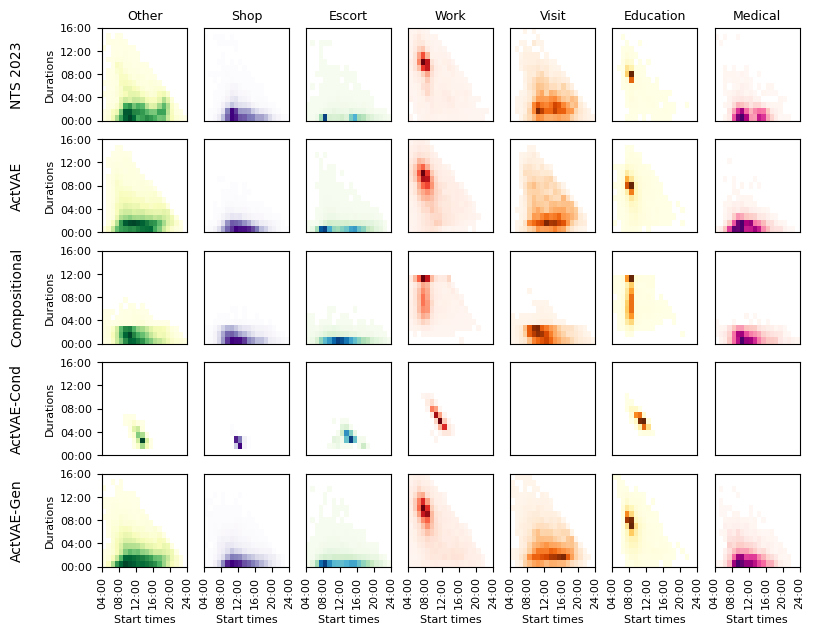

In [120]:
selected = {
    "NTS 2023": target_schedules,
    "ActVAE": schedules["ActVAE"],
    "Compositional": schedules["Compositional"],
    "ActVAE-Cond": schedules["ActVAE-Cond"],
    "ActVAE-Gen": schedules["ActVAE-Gen"],
}

cmaps = {
    "work": "Reds",
    "education": "YlOrBr",
    "shop": "Purples",
    "visit": "Oranges",
    "escort": "GnBu",
    "medical": "RdPu",
    "travel": "Greys",
    "other": "YlGn",
}

fig = time_plot(
    selected, figsize=(9, 7), observed_title="NTS 2023", cmaps=cmaps
)
plt.subplots_adjust(wspace=0.2, hspace=0.2)

In [128]:
import random

from pam.core import Household, Person
from pam.plot.plans import plot_household
from pandas import DataFrame

from caveat.data.utils import trace_to_pam


def stretch(schedules):
    return schedules.groupby(schedules.pid).apply(stretcher)


def stretcher(schedule):
    duration = schedule.duration.sum()
    if duration != 1440:
        a = 1440 / duration
        schedule.duration = (schedule.duration * a).astype(int)
        accumulated = list(schedule.duration.cumsum())
        schedule.start = [0] + accumulated[:-1]
        schedule.end = accumulated
    return schedule


def trim(schedules):
    schedules[schedules.end > 1440] = 1440
    schedules[schedules.start > 1440] = 1440
    schedules.duration = schedules.end - schedules.start
    schedules = schedules[schedules.duration > 0]
    return schedules


def pad(schedules):
    return (
        schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
    )


def padder(schedule):
    if schedule.end.iloc[-1] < 1440 and schedule.act.iloc[-1] != "home":
        pid = schedule.pid.iloc[0]
        schedule = pd.concat(
            [
                schedule,
                DataFrame(
                    {
                        "pid": pid,
                        "start": schedule.end.iloc[-1],
                        "end": 1440,
                        "duration": 1440 - schedule.end.iloc[-1],
                        "act": "home",
                    },
                    index=[0],
                ),
            ]
        )
    elif schedule.end.iloc[-1] < 1440:
        schedule.end.iloc[-1] = 1440
        schedule.duration.iloc[-1] = 1440 - schedule.start.iloc[-1]
    return schedule


def plot_schedules(schedules, **kwargs):
    cmap = kwargs.pop("cmap")
    cmap = {n.title(): c for n, c in cmap.items()}
    if "duration" not in schedules.columns:
        schedules["duration"] = schedules.end - schedules.start
    hh = Household("")
    pids = schedules.pid
    selected = random.sample(list(pids), 8)
    for i, pid in enumerate(selected):
        person = Person(pid)
        plan = schedules[schedules.pid == pid]
        plan = trim(stretch(pad(plan)))[["act", "start", "end", "duration"]]
        mapping = {a: a for a in plan.act}

        trace = [
            (row.act, row.start, row.end, row.duration)
            for i, row in plan.iterrows()
        ]
        plan = trace_to_pam(trace, mapping)

        person = Person(i)
        person.plan = plan
        hh.add(person)

    plot_household(hh, cmap=cmap, width=25)

/tmp/ipykernel_41034/2729459132.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_41034/2729459132.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_41034/2729459132.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This beha

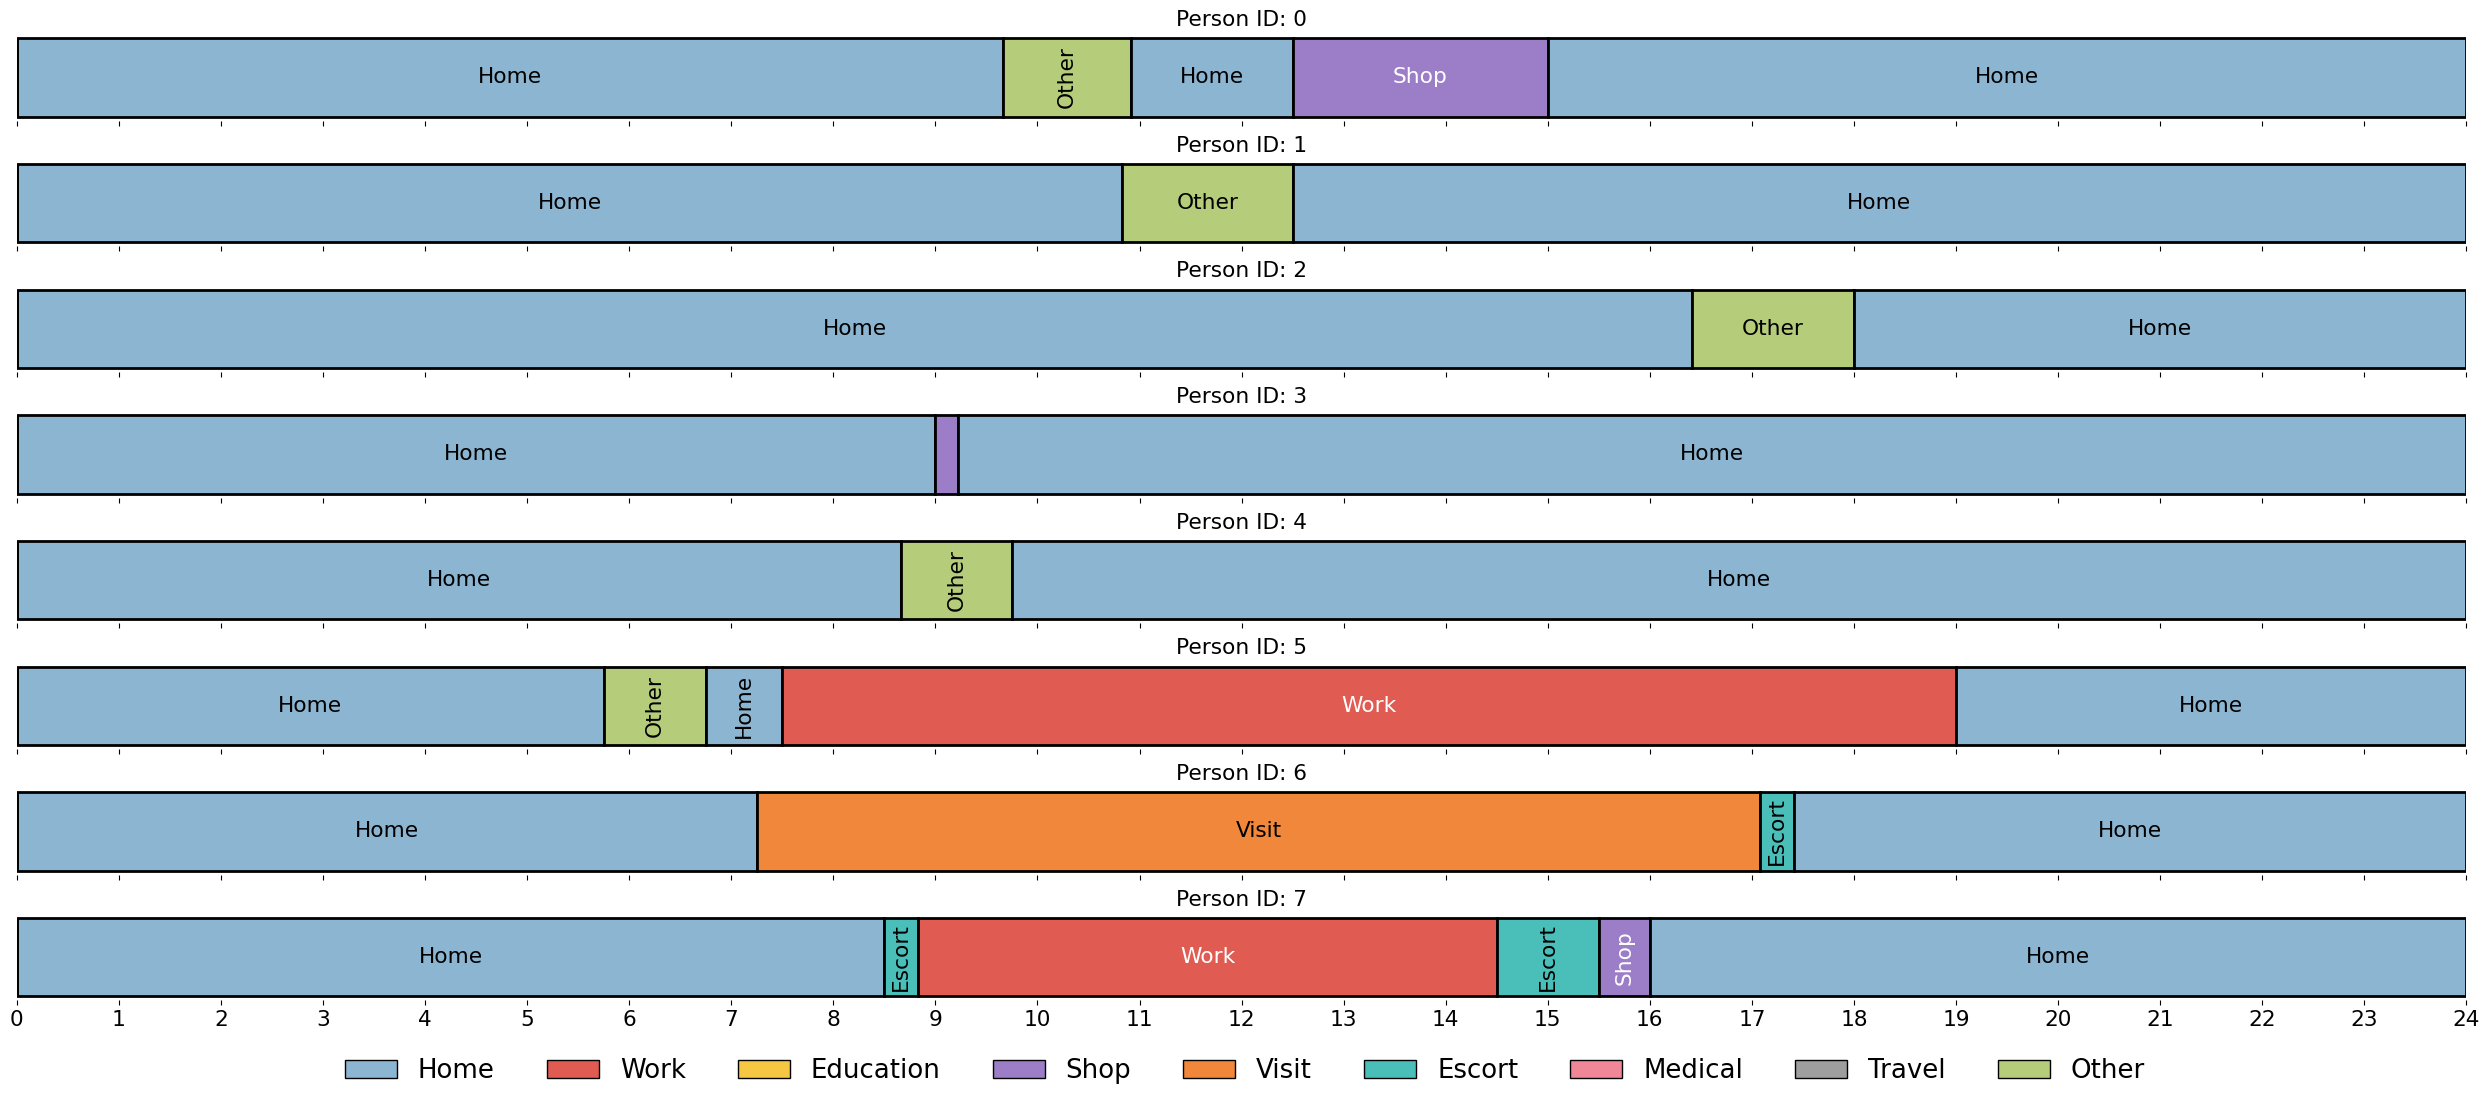

In [ ]:
# plot_schedules(target_schedules, cmap=cmap)

/tmp/ipykernel_41034/2729459132.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_41034/2729459132.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_41034/2729459132.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This beha

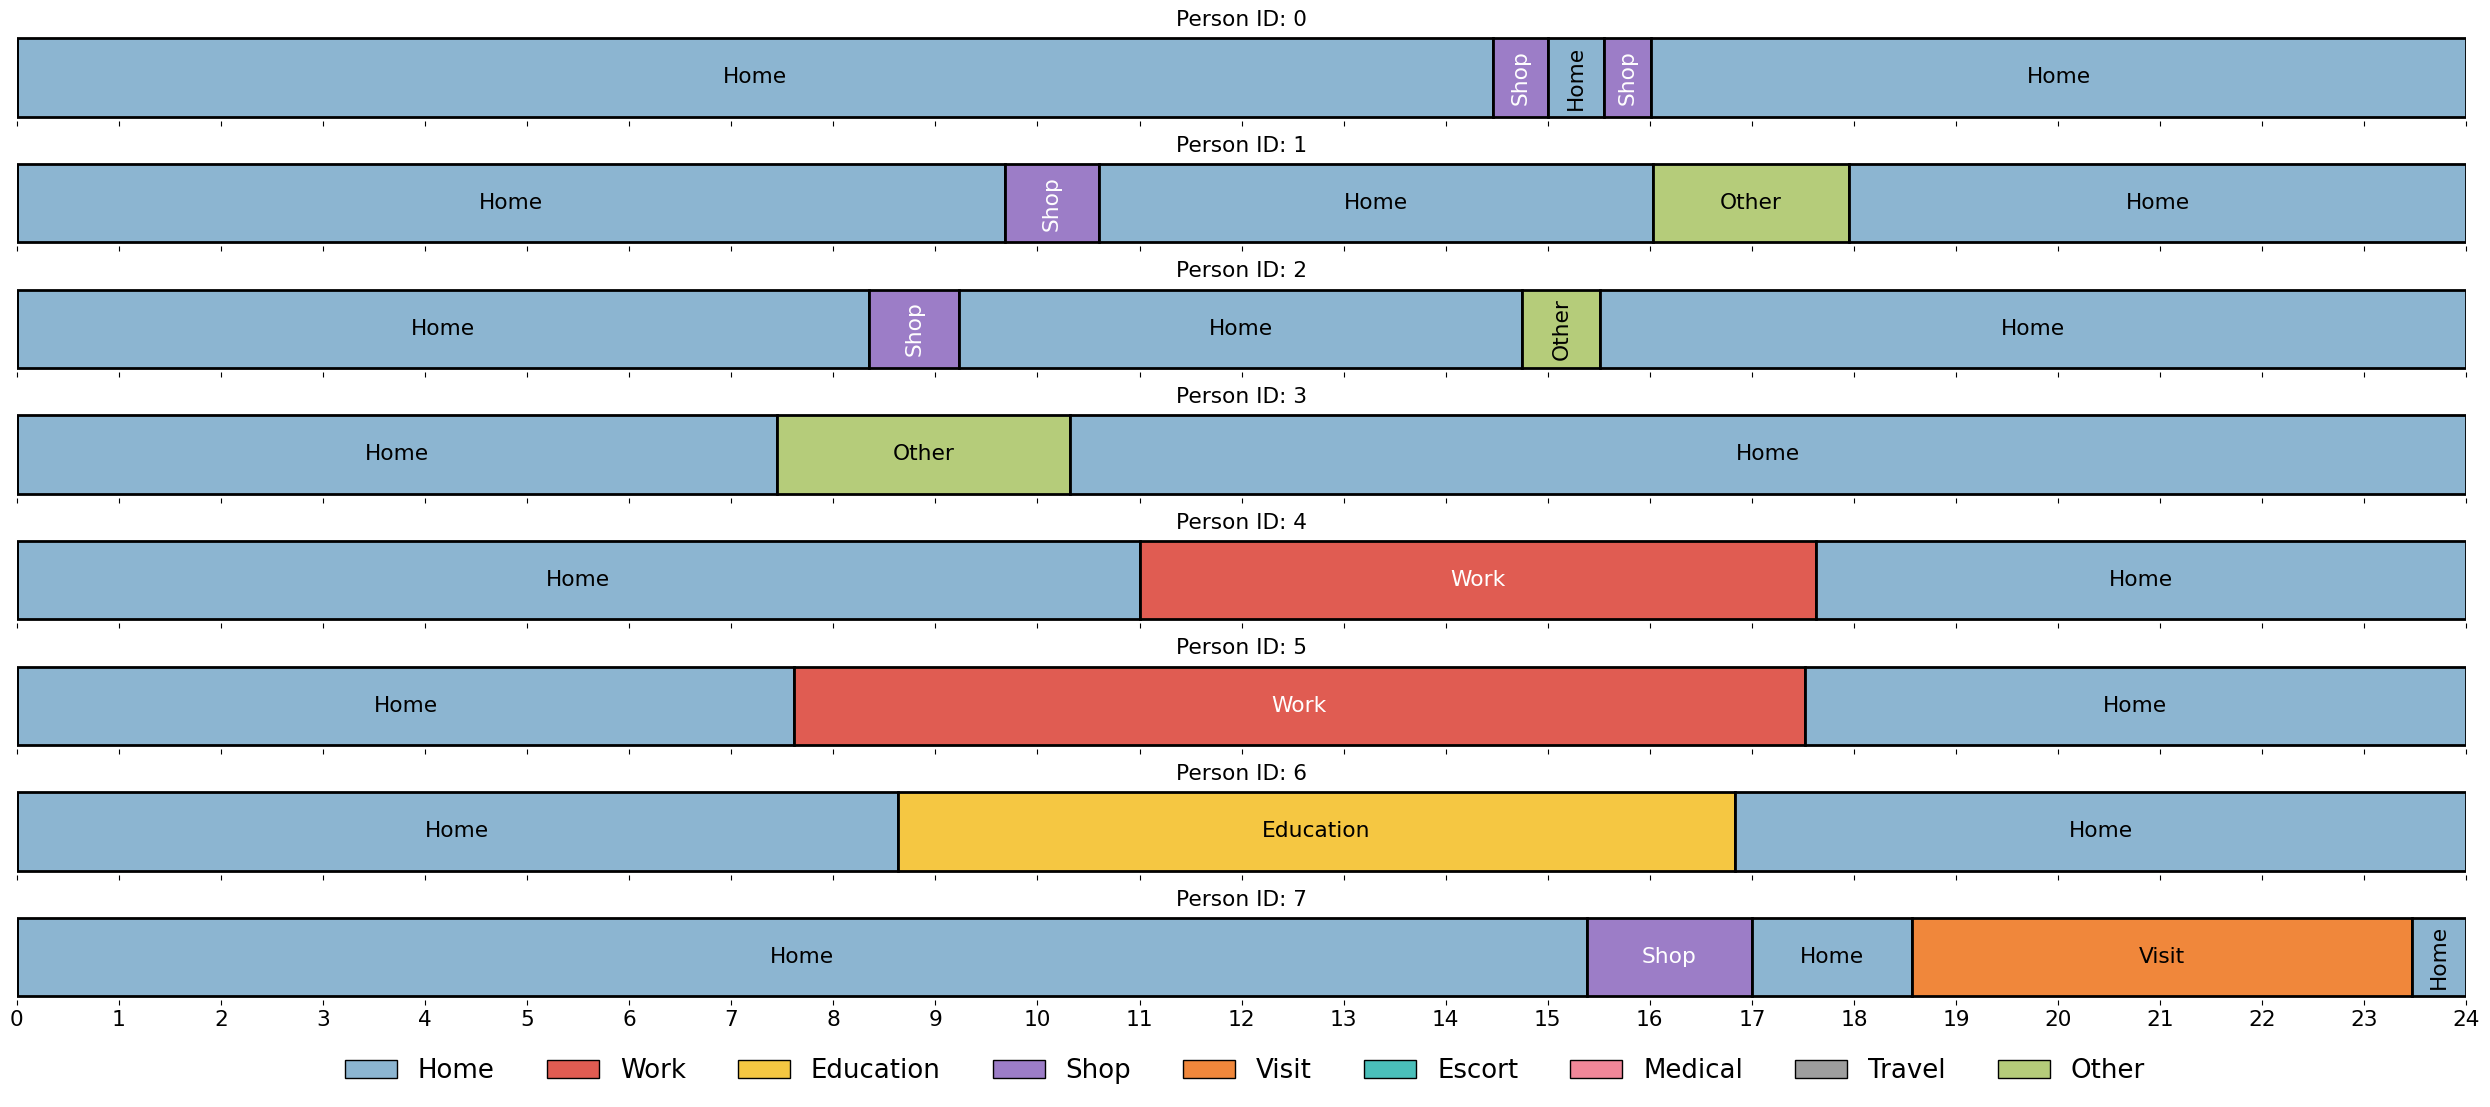

In [ ]:
# plot_schedules(schedules["ActVAE"], cmap=cmap)

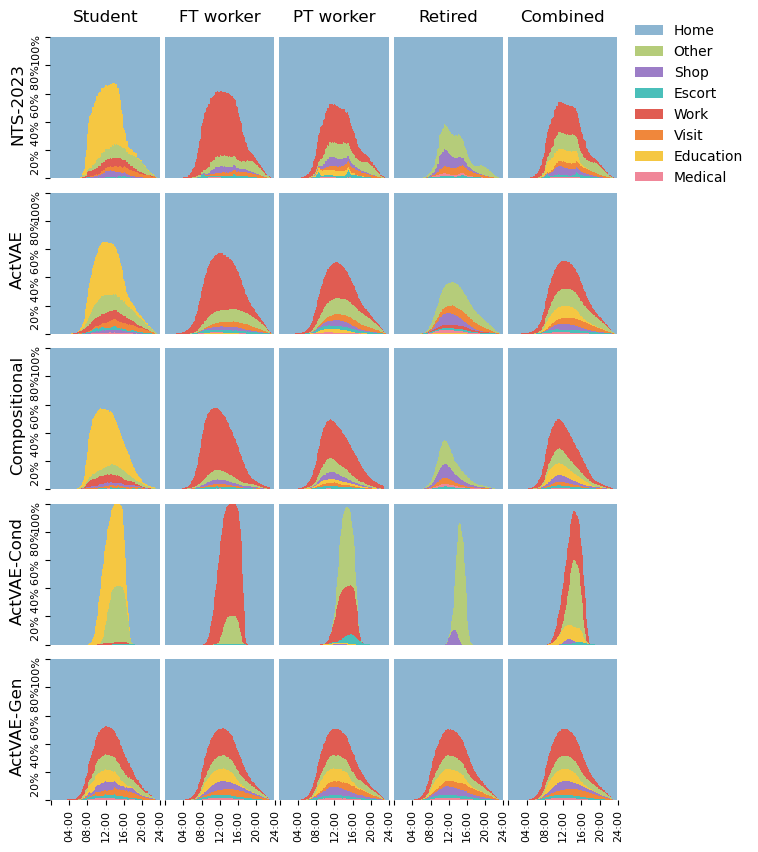

In [141]:
plot_schedules = {
    "NTS-2023": target_schedules,
    "ActVAE": schedules["ActVAE"],
    "Compositional": schedules["Compositional"],
    "ActVAE-Cond": schedules["ActVAE-Cond"],
    "ActVAE-Gen": schedules["ActVAE-Gen"],
}
plot_attributes = {
    "NTS-2023": target_attributes,
    "ActVAE": attributes["ActVAE"],
    "Compositional": attributes["Compositional"],
    "ActVAE-Cond": attributes["ActVAE-Cond"],
    "ActVAE-Gen": attributes["ActVAE-Gen"],
}

act_order = target_schedules.act.value_counts().index.to_list()
class_map = {n: i for i, n in enumerate(act_order)}

FILTER = ["student", "ft-employed", "pt-employed", "retired"]
NAMES = ["Student", "FT worker", "PT worker", "Retired"]

h = len(plot_schedules)
w = len(FILTER)
fig, axes = plt.subplots(
    h, w + 2, figsize=(w * 2.2, h * 2), sharex=False, sharey=False
)

for i, (name, scheds) in enumerate(plot_schedules.items()):

    splits = split_on(scheds, plot_attributes[name], by="employment")

    for j, f in enumerate(FILTER):
        axes[0, j].set_title(NAMES[j], fontsize=12)
        selected = splits[f]
        ax = plot_agg_acts(
            "",
            selected,
            class_map=class_map,
            ax=axes[i, j],
            legend=False,
            color=cmaps,
        )
        ax.set_title(None)
        ax.set_ylabel(None)
        ax.set_xlabel(None)
        ax.set_yticks([])
        ax.set_xticks([])

        axes[-1, j].set_xticks(
            [i / 10 for i in [0, 240, 480, 720, 960, 1200, 1440]],
            labels=["", "04:00", "08:00", "12:00", "16:00", "20:00", "24:00"],
            rotation=90,
            fontsize=8,
        )

    axes[0, -2].set_title("Combined", fontsize=12)
    ax = plot_agg_acts(
        "",
        scheds,
        class_map=class_map,
        ax=axes[i, -2],
        legend=False,
        color=cmaps,
    )
    ax.set_title(None)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.set_yticks([])
    ax.set_xticks([])

    axes[-1, -2].set_xticks(
        [i / 10 for i in [0, 240, 480, 720, 960, 1200, 1440]],
        labels=["", "04:00", "08:00", "12:00", "16:00", "20:00", "24:00"],
        rotation=90,
        fontsize=8,
    )

    axes[i, 0].set_ylabel(name, fontsize=12)
    axes[i, 0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    axes[i, 0].set_yticklabels(
        ["", "20% ", "40% ", "60% ", "80% ", "100%"], rotation=90, fontsize=8
    )

    axes[i, -1].axis("off")

elements = [Patch(facecolor=cmaps[act], label=act.title()) for act in act_order]
axes[0, -1].axis("off")
axes[0, -1].legend(handles=elements, loc="center left", frameon=False)

plt.subplots_adjust(wspace=0.04, hspace=0.05)

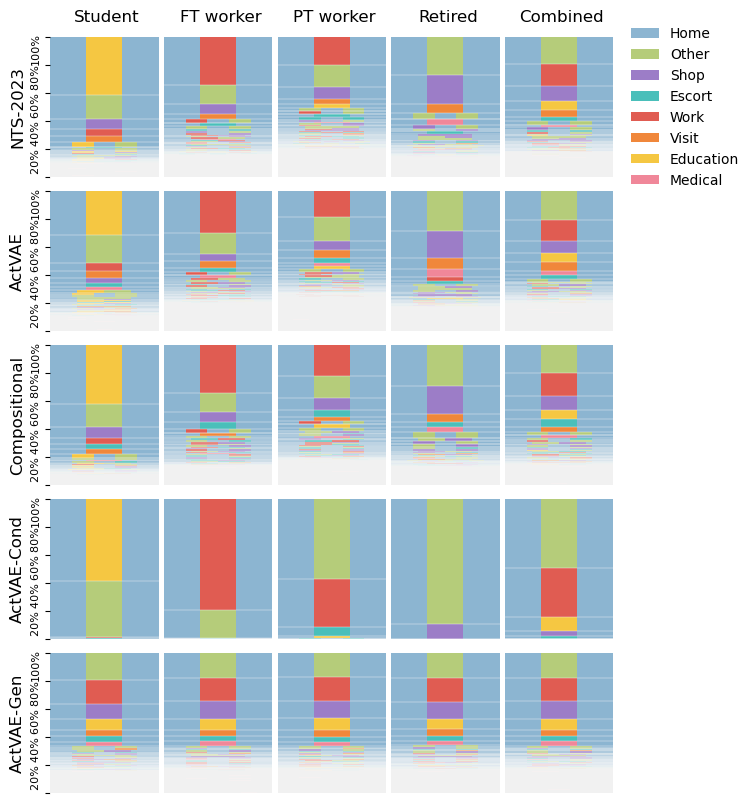

In [142]:
h = len(plot_schedules)
w = len(FILTER)
fig, axes = plt.subplots(
    h, w + 2, figsize=(w * 2.2, h * 2), sharex=False, sharey=False
)

for i, (name, scheds) in enumerate(plot_schedules.items()):

    splits = split_on(scheds, plot_attributes[name], by="employment")

    for j, f in enumerate(FILTER):
        axes[0, j].set_title(NAMES[j], fontsize=12)
        selected = splits[f]
        ax = _probs_plot("", selected, cmap=cmaps, ax=axes[i, j])
        ax.set_title(None)
        ax.set_ylabel(None)
        ax.set_xlabel(None)
        ax.set_yticks([])
        ax.set_xticks([])

    axes[0, -2].set_title("Combined", fontsize=12)
    ax = _probs_plot("", scheds, cmap=cmaps, ax=axes[i, -2])
    ax.set_title(None)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.set_yticks([])
    ax.set_xticks([])

    axes[i, 0].set_ylabel(name, fontsize=12)
    axes[i, 0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    axes[i, 0].set_yticklabels(
        ["", "20% ", "40% ", "60% ", "80% ", "100%"], rotation=90, fontsize=8
    )

    axes[i, -1].axis("off")

elements = [Patch(facecolor=cmaps[act], label=act.title()) for act in act_order]
axes[0, -1].axis("off")
axes[0, -1].legend(handles=elements, loc="center left", frameon=False)


plt.subplots_adjust(wspace=0, hspace=0)

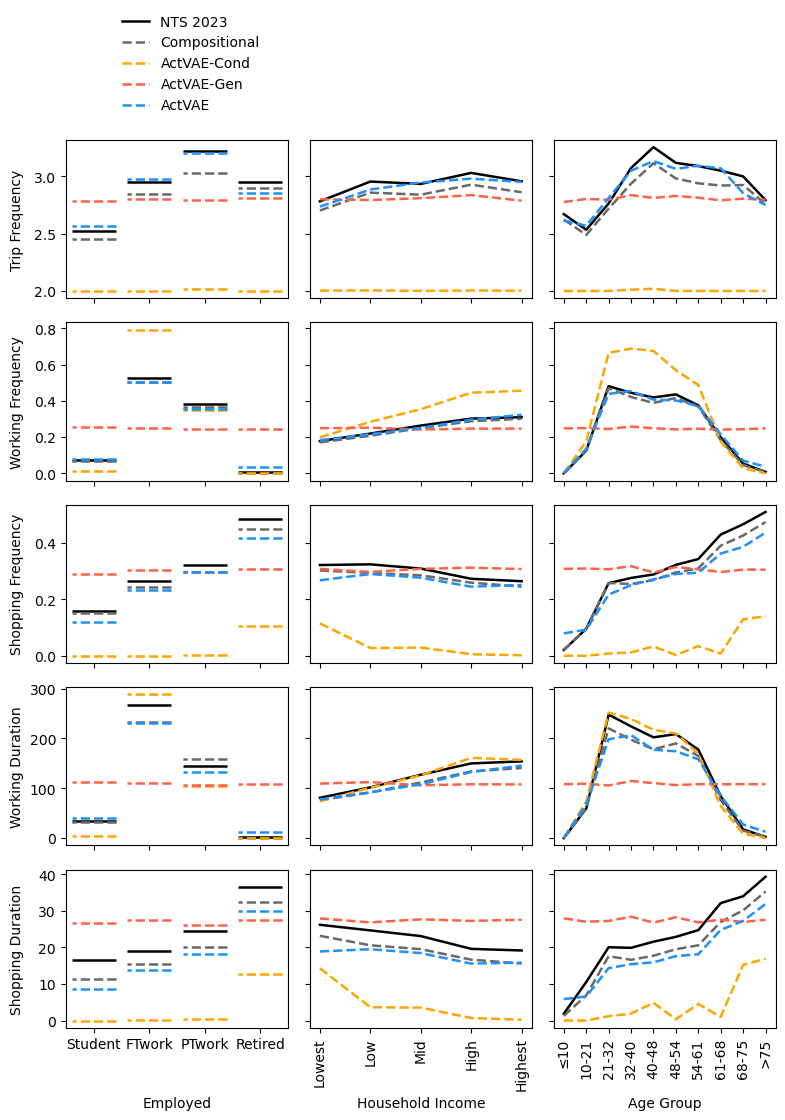

In [222]:
def duration(schedules, act="work"):
    if "duration" not in schedules.columns:
        durations = schedules.end - schedules.start
    else:
        durations = schedules.duration
    filtered = durations[schedules.act == act]
    n = schedules.pid.nunique()
    return filtered.sum(0) / n


def count_trips(schedules):
    n = schedules.pid.nunique()
    return (len(schedules) - n) / n


def count_acts(schedules, act="work"):
    n = schedules.pid.nunique()
    return len(schedules.loc[schedules.act == act]) / n


def plot_conditionals(
    schedules, attributes, target_schedules, target_attributes, figsize=(8, 10)
):
    WORK_STATUS = "employment"
    INCOME = "hh_income"
    AGE = "age"

    work_order = [
        # "retired",
        # "unemployed",
        "student",
        "ft-employed",
        "pt-employed",
        "retired",
    ]
    work_statuses = ["Student", "FTwork", "PTwork", "Retired"]

    age_order = [
        "≤10",
        "10-21",
        "21-32",
        "32-40",
        "40-48",
        "48-54",
        "54-61",
        "61-68",
        "68-75",
        ">75",
    ]
    ages = [
        "≤10",
        "10-21",
        "21-32",
        "32-40",
        "40-48",
        "48-54",
        "54-61",
        "61-68",
        "68-75",
        ">75",
    ]
    incomes = ["≤22316", "22316-32118", "32118-44107", "44107-68887", ">68887"]
    colours = [
        "black",
        "dimgray",
        "orange",
        "tomato",
        "dodgerblue",
        "grey",
        "black",
        "lightgrey",
        "pink",
        "green",
    ]
    styles = ["-", "--", "--", "--", "--", ":", ":", ":", ":", ":", ":"]
    LW = 1.8

    fig, axs = plt.subplots(5, 3, figsize=figsize, sharex="col", sharey="row")

    # ==============================
    # trips employment
    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[0][0]
    # change to bar plot
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Trip Frequency")
    ax.legend().remove()

    # ==============================
    # trips income
    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[0][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ==================================
    # trips age group
    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # =================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[1][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Working Frequency")
    ax.legend().remove()

    # =================================
    # work income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[1][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # =================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[2][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Shopping Frequency")
    ax.legend().remove()

    # =================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[2][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[3][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.legend().remove()
    ax.set_ylabel("Working Duration")

    # ====================================
    # work income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[3][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[4][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )

    ax.legend().remove()
    ax.set_xlim(-0.5, 3.5)

    ax.set_ylabel("Shopping Duration")
    ax.set_xlabel("Employed")
    ax.set_xticks(list(range(len(work_order))), work_statuses, rotation=0)

    # ====================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[4][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()
    ax.set_xlabel("Household Income")
    ax.set_xticks(
        [0, 1, 2, 3, 4],
        ["Lowest", "Low", "Mid", "High", "Highest"],
        rotation=90,
    )

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][2]
    df.loc[age_order].plot.line(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()
    ax.set_xlabel("Age Group")
    ax.set_xticks(range(len(ages)), ages, rotation=90)

    # for ax in axs.flat:
    #     ax.grid(visible=True, which="major", axis="x", color="grey", linestyle="-")

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0.25, 1),
    )

    fig.align_ylabels(axs[:, 0])
    fig.align_xlabels(axs[-1, :])

    fig.tight_layout()


plot_conditionals(schedules, attributes, target_schedules, target_attributes)

In [ ]:
attributes["ActVAE"].access_egress_distance.value_counts().sort_values(
    ascending=False
).head(10)

access_egress_distance
3.376-5.8       11191
9.15862-15.8    11175
≤3.376          11165
>15.8           11150
5.8-9.15862     11132
unknown           921
Name: count, dtype: int64

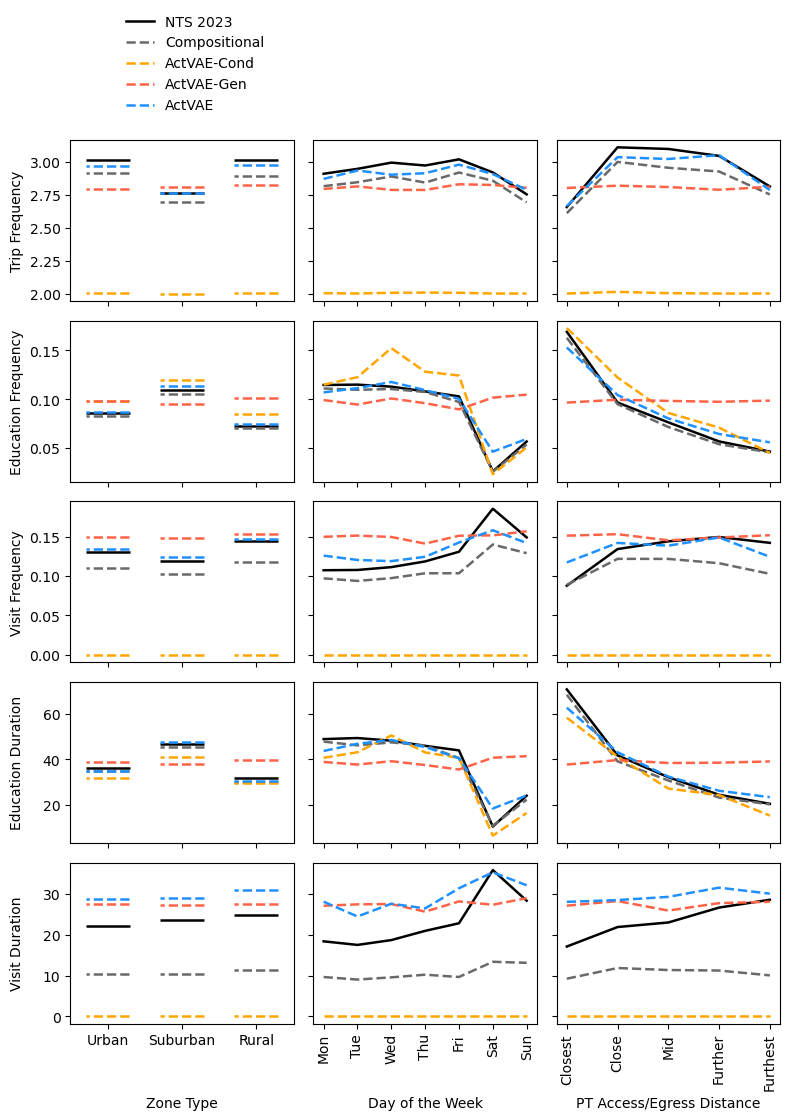

In [ ]:
def plot_conditionals2(
    schedules, attributes, target_schedules, target_attributes, figsize=(8, 10)
):
    ZONE = "hh_zone"
    DAY = "day"
    AEDISTANCE = "access_egress_distance"

    ACT1 = "education"
    ACT2 = "visit"

    zone_order = ["urban", "suburban", "rural"]
    zones = ["Urban", "Suburban", "Rural"]
    aeorder = ["≤3.376", "3.376-5.8", "5.8-9.15862", "9.15862-15.8", ">15.8"]
    aedistances = ["Closest", "Close", "Mid", "Further", "Furthest"]
    day_order = [
        "monday",
        "tuesday",
        "wednesday",
        "thursday",
        "friday",
        "saturday",
        "sunday",
    ]
    days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

    colours = [
        "black",
        "dimgray",
        "orange",
        "tomato",
        "dodgerblue",
        "grey",
        "black",
        "lightgrey",
        "pink",
        "green",
    ]
    styles = ["-", "--", "--", "--", "--", ":", ":", ":", ":", ":", ":"]
    LW = 1.8

    fig, axs = plt.subplots(5, 3, figsize=figsize, sharex="col", sharey="row")

    # ==============================
    # trips employment
    splits = split_on(target_schedules, target_attributes, by=ZONE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=ZONE)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    df = df.loc[zone_order]
    ax = axs[0][0]
    # change to bar plot
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Trip Frequency")
    ax.legend().remove()

    # ==============================
    # trips income
    splits = split_on(target_schedules, target_attributes, by=DAY)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=DAY)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    df = df.loc[day_order]
    ax = axs[0][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ==================================
    # trips age group
    splits = split_on(target_schedules, target_attributes, by=AEDISTANCE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AEDISTANCE)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][2]
    df.loc[aeorder].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # =================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by=ZONE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act=ACT1)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=ZONE)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act=ACT1)

    df = pd.DataFrame(data)
    df = df.loc[zone_order]
    ax = axs[1][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Education Frequency")
    ax.legend().remove()

    # =================================
    # work income

    splits = split_on(target_schedules, target_attributes, by=DAY)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act=ACT1)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=DAY)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act=ACT1)

    df = pd.DataFrame(data)
    df = df.loc[day_order]
    ax = axs[1][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by=AEDISTANCE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act=ACT1)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AEDISTANCE)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act=ACT1)

    df = pd.DataFrame(data)
    ax = axs[1][2]
    df.loc[aeorder].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # =================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by=ZONE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act=ACT2)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=ZONE)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act=ACT2)

    df = pd.DataFrame(data)
    df = df.loc[zone_order]
    ax = axs[2][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Visit Frequency")
    ax.legend().remove()

    # =================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by=DAY)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act=ACT2)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=DAY)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act=ACT2)

    df = pd.DataFrame(data)
    df = df.loc[day_order]
    ax = axs[2][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by=AEDISTANCE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act=ACT2)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AEDISTANCE)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act=ACT2)

    df = pd.DataFrame(data)
    ax = axs[2][2]
    df.loc[aeorder].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by=ZONE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act=ACT1)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=ZONE)
        for i, split in splits.items():
            data[n][i] = duration(split, act=ACT1)

    df = pd.DataFrame(data)
    df = df.loc[zone_order]
    ax = axs[3][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.legend().remove()
    ax.set_ylabel("Education Duration")

    # ====================================
    # work income

    splits = split_on(target_schedules, target_attributes, by=DAY)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act=ACT1)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=DAY)
        for i, split in splits.items():
            data[n][i] = duration(split, act=ACT1)

    df = pd.DataFrame(data)
    df = df.loc[day_order]
    ax = axs[3][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by=AEDISTANCE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act=ACT1)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AEDISTANCE)
        for i, split in splits.items():
            data[n][i] = duration(split, act=ACT1)

    df = pd.DataFrame(data)
    ax = axs[3][2]
    df.loc[aeorder].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by=ZONE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act=ACT2)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=ZONE)
        for i, split in splits.items():
            data[n][i] = duration(split, act=ACT2)

    df = pd.DataFrame(data)
    df = df.loc[zone_order]
    ax = axs[4][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )

    ax.legend().remove()
    ax.set_xlim(-0.5, 2.5)

    ax.set_ylabel("Visit Duration")
    ax.set_xlabel("Zone Type")
    ax.set_xticks(list(range(len(zone_order))), zones, rotation=0)

    # ====================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by=DAY)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act=ACT2)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=DAY)
        for i, split in splits.items():
            data[n][i] = duration(split, act=ACT2)

    df = pd.DataFrame(data)
    df = df.loc[day_order]
    ax = axs[4][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()
    ax.set_xlabel("Day of the Week")
    ax.set_xticks(range(len(days)), days, rotation=90)

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by=AEDISTANCE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act=ACT2)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AEDISTANCE)
        for i, split in splits.items():
            data[n][i] = duration(split, act=ACT2)

    df = pd.DataFrame(data)
    ax = axs[4][2]
    df.loc[aeorder].plot.line(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()
    ax.set_xlabel("PT Access/Egress Distance")
    ax.set_xticks(range(len(aedistances)), aedistances, rotation=90)

    # for ax in axs.flat:
    #     ax.grid(visible=True, which="major", axis="x", color="grey", linestyle="-")

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0.25, 1),
    )

    fig.align_ylabels(axs[:, 0])
    fig.align_xlabels(axs[-1, :])

    fig.tight_layout()


plot_conditionals2(schedules, attributes, target_schedules, target_attributes)

In [214]:
# ablations
ablation_paths = {
    "ActVAE": Path("../logs/actvae/cpvae"),
    "No prior": Path("../logs/actvae/cvae"),
    "No add": Path("../logs/actvae/cpvae-none"),
    "VAE": Path("../logs/actvae/vae/"),
}

order = ["participations", "transitions", "timing"]
df = build_distance_tables(ablation_paths)
df = df.loc[order]
df

ActVAE                No prior              No add  \
                     EMD           var       EMD       var       EMD   
domain                                                                 
participations  0.083007  1.567493e-05  0.132332  0.000199  0.092773   
transitions     0.003833  4.485888e-07  0.005790  0.000001  0.005026   
timing          0.046785  2.177686e-06  0.057808  0.000005  0.055205   

                                   VAE                
                         var       EMD           var  
domain                                                
participations  1.516414e-04  0.117443  6.505279e-06  
transitions     1.191701e-07  0.006664  1.228678e-07  
timing          1.886757e-05  0.056512  3.933448e-06

In [215]:
dist_dist, dist_std, dist_desc = group_tables(ablation_paths)
dist_dist = dist_dist.query(
    "domain in ['feasibility', 'creativity']"
).droplevel(0, axis=0)
for mod in ["ActVAE", "No prior", "No add", "VAE"]:
    dist_dist.loc[:, (mod, "mean")] = 1 - dist_dist[mod]["mean"]
dist_dist

ActVAE ['cpvae-add_nrun0', 'cpvae-add_nrun2', 'cpvae-add_nrun3', 'cpvae-add_nrun4', 'cpvae-add_nrun1']
No prior ['cvae_nrun1', 'cvae_nrun3', 'cvae_nrun4', 'cvae_nrun0', 'cvae_nrun2']
No add ['cpvae-none_nrun0', 'cpvae-none_nrun2', 'cpvae-none_nrun1']
VAE ['vae_nrun3', 'vae_nrun2', 'vae_nrun4', 'vae_nrun1', 'vae_nrun0']


ActVAE                No prior                  No add  \
                    mean           var      mean           var      mean   
feature                                                                    
consecutive     0.985790  2.450026e-06  0.980092  3.897614e-05  0.991745   
invalid         0.985330  2.520793e-06  0.980075  3.873522e-05  0.991242   
not home based  0.999523  2.544597e-07  0.999983  8.835060e-10  0.999456   
conservatism    0.969020  4.957297e-08  0.970080  6.989672e-08  0.969812   
homogeneity     0.967429  4.419667e-07  0.969588  2.096269e-07  0.968580   

                                   VAE                
                         var      mean           var  
feature                                               
consecutive     3.630895e-06  0.985080  7.512942e-05  
invalid         5.154299e-06  0.984953  7.636629e-05  
not home based  2.330111e-07  0.999863  4.538285e-08  
conservatism    1.316751e-07  0.970129  1.543097e-07  
homogeneity     2.839023e-08  0.969601  1.220258e-06

In [216]:
diffs = pd.DataFrame()
differs = pd.DataFrame()
for mod in ["No prior", "No add", "VAE"]:
    diffs[f"{mod} diff"] = (
        100 * (df[mod]["EMD"] - df["ActVAE"]["EMD"]) / df[mod]["EMD"]
    )
    differs[f"{mod} diff"] = (
        100
        * (dist_dist[mod]["mean"] - dist_dist["ActVAE"]["mean"])
        / dist_dist[mod]["mean"]
    )

df = pd.concat([diffs, differs])

df

,No prior diff,No add diff,VAE diff
participations,37.273250,10.526045,29.320958
transitions,33.810085,23.747564,42.489344
timing,19.068492,15.251460,17.212050
consecutive,-0.581427,0.600470,-0.072110
invalid,-0.536256,0.596378,-0.038315
not home based,0.045998,-0.006649,0.033986
conservatism,0.109294,0.081670,0.114308
homogeneity,0.222737,0.118826,0.224016


In [217]:
print(df.to_latex(float_format="{:.1f}\%".format))

\begin{tabular}{lrrr}
\toprule
 & No prior diff & No add diff & VAE diff \\
\midrule
participations & 37.3\% & 10.5\% & 29.3\% \\
transitions & 33.8\% & 23.7\% & 42.5\% \\
timing & 19.1\% & 15.3\% & 17.2\% \\
consecutive & -0.6\% & 0.6\% & -0.1\% \\
invalid & -0.5\% & 0.6\% & -0.0\% \\
not home based & 0.0\% & -0.0\% & 0.0\% \\
conservatism & 0.1\% & 0.1\% & 0.1\% \\
homogeneity & 0.2\% & 0.1\% & 0.2\% \\
\bottomrule
\end{tabular}



<>:1: SyntaxWarning: invalid escape sequence '\%'
<>:1: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_41034/2017725803.py:1: SyntaxWarning: invalid escape sequence '\%'
  print(df.to_latex(float_format="{:.1f}\%".format))


In [ ]:
# Ageing Scenario
attributes = {
    2023: pd.read_csv(Path("../tmp/nomis_ages_2023.csv")),
    2030: pd.read_csv(Path("../tmp/nomis_ages_2030.csv")),
    2040: pd.read_csv(Path("../tmp/nomis_ages_2040.csv")),
    2050: pd.read_csv(Path("../tmp/nomis_ages_2050.csv")),
}
demographics = pd.DataFrame(
    {year: a.age_group.value_counts() for year, a in attributes.items()}
).loc[
    ["<5", "5-11", "11-16", "16-20", "20-30", "30-40", "40-50", "50-70", "70+"]
]
print(demographics.sum(axis=0))
demographics

In [ ]:
# add zero row at top, i.e:
#     0, 0, 0, 0, 0
new_row = pd.DataFrame({year: 0 for year in demographics.columns}, index=["0"])
demographics = pd.concat([new_row, demographics])
demographics

In [ ]:
scaled = demographics * 100 / 1000000

scaled["duration"] = [1, 5, 6, 5, 4, 10, 10, 10, 20, 20]
for year in [2023, 2030, 2040, 2050]:
    scaled[year] = scaled[year] / scaled.duration
scaled.duration = scaled.duration.cumsum() - 1

fig, ax = plt.subplots(figsize=(6, 3))

# Use a colorblind-friendly palette from matplotlib
colors = [
    "#0072B2",
    "#009E73",
    "#D55E00",
    "#CC79A7",
]  # blue, green, orange, purple
linestyles = ["-", "-.", "--", ":"]

for year, c, linestyle in zip([2023, 2030, 2040, 2050], colors, linestyles):
    ax.step(
        scaled.duration,
        scaled[year],
        label=str(year),
        color=c,
        linestyle=linestyle,
        linewidth=2,
    )
# for y in scaled.index:
#     ax.axhline(y, color="lightgrey", linestyle="--", linewidth=0.5, zorder=0)

ax.set_ylabel("Density (millions per year)")
ax.set_xlabel("Age Group")
ax.legend(scaled.columns, loc="lower center", frameon=False, title_fontsize=12)
# ax.set_xlim(0, 20)

In [ ]:
scaled

In [ ]:
aged_schedule_paths = {
    n[1:]: Path("../logs/TRB/cvae_nomis_scenario") / n / "version_1"
    for n in ["a2023", "a2030", "a2040", "a2050"]
}
age_schedules = {
    n: pd.read_csv(p / "synthetic_schedules.csv")
    for n, p in aged_schedule_paths.items()
}
age_attributes = {
    n: pd.read_csv(p / "synthetic_attributes.csv")
    for n, p in aged_schedule_paths.items()
}
age_target = age_schedules.pop("2023")
age_attributes_target = age_attributes.pop("2023")

In [ ]:
fig = frequency_plots(
    age_target,
    age_schedules,
    color=cmaps,
    figsize=(8, 3.5),
    observed_title="NTS 2023",
)
fig = sequence_prob_plot(
    age_target,
    age_schedules,
    cmap=cmaps,
    figsize=(8, 3.5),
    observed_title="2023",
)

In [ ]:
# for k, scheds in age_schedules.items():
#     splits = split_on(scheds, age_attributes[k], by="age_group")
#     fig = describe_transitions.sequence_prob_plot(
#         scheds, splits, observed_title="All", cmap=cmap, figsize=(16, 3.5)
#     )

In [ ]:
aged_scenario = Path(
    "../logs/TRB/cvae_nomis_scenario/label_descriptions_subs.csv"
)
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment", "cat"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations", "participation rate"),
    ["a2023", "a2030", "a2040", "a2050"],
]
aged_scenario = aged_scenario.reset_index()
aged_scenario = aged_scenario.loc[aged_scenario.segment == "education"].drop(
    "segment", axis=1
)
aged_scenario = aged_scenario.set_index("cat")
aged_scenario = aged_scenario.loc[
    ["<5", "5-11", "11-16", "16-20", "20-30", "30-40", "40-50", "50-70", "70+"]
]
# aged_scenario = aged_scenario.pivot(columns="cat")
aged_scenario

In [ ]:
aged_scenario = Path("../logs/TRB/cvae_nomis_scenario/descriptions.csv")
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations"), ["a2023", "a2030", "a2040", "a2050"]
]
aged_scenario = aged_scenario.drop("pair participation rate", axis=0)
aged_scenario

In [ ]:
aged_scenario = Path("../logs/TRB/cvae_nomis_scenario/descriptions.csv")
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations"), ["a2023", "a2030", "a2040", "a2050"]
]
# aged_scenario = aged_scenario.loc["participation rate"]
aged_scenario = aged_scenario.drop("pair participation rate", axis=0)
for c in ["a2030", "a2040", "a2050"]:
    aged_scenario[c] = aged_scenario[c].astype(float)
    aged_scenario[f"{c}"] = (
        100
        * (aged_scenario[c] - aged_scenario["a2023"])
        / aged_scenario["a2023"]
    )
aged_scenario = aged_scenario.sort_values(by="a2023", ascending=False)
print(
    aged_scenario.to_latex(
        float_format="{:.3f}".format, index=True, label="tab:aged_scenario"
    )
)
aged_scenario

In [ ]:
schedules = {
    year: pd.read_csv(
        latest(Path("../logs/TRB/cvae_ageing_scenario") / f"a{year}")[1]
        / "synthetic_schedules.csv"
    )
    for year in ["2023", "2033", "2043", "2053"]
}

base = schedules.pop("2023")

fig = joint_time_distributions_plot(
    base,
    schedules,
    figsize=(8, 6),
    observed_title="2023",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)
fig = frequency_plots(
    base, schedules, color=cmaps, figsize=(8, 3.5), observed_title="2023"
)
fig = describe_transitions.sequence_prob_plot(
    base, schedules, observed_title="2023", cmap=cmaps, figsize=(8, 3.5)
)

In [ ]:
sample_scenario = Path(
    "../logs/TRB/cvae_sampled_scenario/domain_distances_subs.csv"
)
sample_scenario = (
    pd.read_csv(sample_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    sample_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["s200", "s100", "s50", "s25", "s12"],
    ].to_latex(float_format="{:.3f}".format)
)

In [ ]:
s200 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s200"))[1]
    / "synthetic_schedules.csv"
)
s100 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s100"))[1]
    / "synthetic_schedules.csv"
)

s50 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s50"))[1]
    / "synthetic_schedules.csv"
)
s25 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s25"))[1]
    / "synthetic_schedules.csv"
)
s12 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s12"))[1]
    / "synthetic_schedules.csv"
)
# s6 = pd.read_csv(
#     latest(Path("../logs/TRB/cvae_sampled_scenario/s6"))[1]
#     / "synthetic_schedules.csv"
# )

sampled_schedules = {
    "200k": s200,
    "100k": s100,
    "50k": s50,
    "25k": s25,
    "12.5k": s12,
}

fig = times_distributions_plot(
    target_schedules,
    sampled_schedules,
    observed_title="NTS 2023",
    figsize=(9, 5),
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmaps,
    figsize=(9, 3.5),
    observed_title="NTS 2023",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="NTS 2023",
    cmap=cmaps,
    figsize=(9, 3.5),
)

In [ ]:
# # labels scenario
label_scenario = Path("../logs/TRB/cvae_labels_scenario/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8", "l16"]]

In [ ]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/domain_distances_subs.csv"
)
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8"]]

In [ ]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/label_descriptions_subs.csv"
)
label_scenario = pd.read_csv(label_scenario)
label_scenario = label_scenario.loc[
    label_scenario.cat.isin(["employed", "unemployed"])
]
label_scenario = label_scenario.set_index(
    ["domain", "feature", "segment", "label", "cat"]
).drop("unit", axis=1)


def aggregate_label_scenario(label_scenario):
    agg = {}
    for c in ["observed", "l1", "l2", "l4", "l8"]:
        agg[c] = (
            label_scenario[c] * label_scenario[f"{c}__weight"]
        ).sum() / label_scenario[f"{c}__weight"].sum()
    return pd.Series(agg)


label_scenario.groupby(["domain", "cat"]).apply(aggregate_label_scenario)

In [ ]:
l1 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l1"))[1]
    / "synthetic_schedules.csv"
)

l2 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l2"))[1]
    / "synthetic_schedules.csv"
)
l4 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l4"))[1]
    / "synthetic_schedules.csv"
)
l8 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l8"))[1]
    / "synthetic_schedules.csv"
)
l16 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l16"))[1]
    / "synthetic_schedules.csv"
)

sampled_schedules = {"L=1": l1, "L=2": l2, "L=4": l4, "L=8": l8, "L=16": l16}

fig = times_distributions_plot(
    target_schedules,
    sampled_schedules,
    observed_title="NTS 2023",
    figsize=(9, 5),
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmaps,
    figsize=(9, 3.5),
    observed_title="NTS 2023",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="NTS 2023",
    cmap=cmaps,
    figsize=(9, 3.5),
)

In [ ]:
# transfer scenario
label_scenario = Path("../logs/TRB/cvae_foundation/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["unconditioned", "conditioned"],
    ].to_latex(float_format="{:.3f}".format)
)

label_scenario = Path("../logs/TRB/cvae_foundation/domain_distances_subs.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["unconditioned", "conditioned"],
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario

In [ ]:
for n in ["aggregate", "participations", "transitions", "timing"]:
    print(n)
    print(table.loc[n].to_latex(float_format="{:.3f}".format))
    print()

In [ ]:
def build_creativity_table(batch_paths):
    descriptions_combined = pd.DataFrame()
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = (
            pd.read_csv(path / "descriptions.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )
        distances = (
            pd.read_csv(path / "distances.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )

        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
            - weights
        )

        descriptions_combined[name, "desc."] = descriptions[columns].mean(
            axis=1
        )

        distances_combined[name, "dist."] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["description"]

    print(descriptions_combined.columns)

    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    distances_combined["Observed", ""] = distances["observed"]
    distances_combined["Description", ""] = distances["distance"]

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    descriptions_combined = descriptions_combined.loc[:, order]

    order = list(distances_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    distances_combined = distances_combined.loc[:, order]

    return pd.concat((descriptions_combined, distances_combined), axis=0)


table = build_creativity_table(batch_paths)
table

In [ ]:
print(table.loc["sample quality"].to_latex(float_format="{:.3f}".format))
table.loc["sample quality"]

In [ ]:
table.loc["creativity"]

In [ ]:
print(table.to_latex(float_format="{:.3f}".format))

In [ ]:
for domain in [
    "creativity",
    "sample quality",
    "aggregate",
    "participations",
    "transitions",
    "timing",
]:
    print()
    print(domain)
    print()
    ss = table.loc[domain]
    for feature in set(ss.reset_index()["feature"]):
        print(feature)
        print()
        print(ss.loc[feature].to_latex(float_format="{:.3f}".format))

In [ ]:
def build_subs_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions_subs.csv").set_index(
            ["domain", "feature", "segment", "sub_pop"]
        )
        columns = set(descriptions.columns)
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
        )

        descriptions_combined[name] = descriptions[columns].mean(axis=1)

    descriptions_combined["Observed"] = descriptions["observed"]
    descriptions_combined["Description"] = descriptions["description"]

    descriptions_combined = (
        descriptions_combined.sort_values("Observed", ascending=False)
        .groupby(["domain", "feature", "sub_pop"])
        .head(100)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index("Observed"))
    order = ["Observed"] + order

    index = [
        "creativity",
        "sample quality",
        "aggregate",
        "participations",
        "transitions",
        "timing",
    ]

    return descriptions_combined.loc[index, order]


table = build_subs_description_tables(batch_paths)
table

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "work0",
    ["work_status=student", "work_status=employed"],
]

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "education0",
    ["work_status=student", "work_status=employed"],
]